# Stepwise Phenotyping Models for Predicting Alzheimer’s Disease Progression

## Research question

**How much demographic, clinical, cognitive, genetic, MRI, and biomarker information is necessary to predict 2-year Alzheimer’s disease progression?**

This notebook is a second analysis notebook. It does **not** replace the first minimal-marker notebook. The first notebook focused on identifying small marker panels for 2-year MCI-to-dementia conversion. This notebook extends that work by testing a **stepwise phenotyping ladder** based on Professor Galasko’s feedback.

## Outcomes

### Primary outcome
- **Binary progression:** MCI-to-dementia conversion within 2 years.

### Secondary outcomes
- **2-year MMSE change**
- **2-year MoCA change**
- **2-year CDR Sum of Boxes change**

For MMSE/MoCA, negative change means cognitive decline.  
For CDR-SB, positive change means worsening global impairment.

## Stepwise phenotyping ladder

The notebook compares prediction as more data layers are added:

1. Demographics only  
2. Demographics + basic clinical variables  
3. Demographics + MMSE  
4. Demographics + MoCA  
5. Demographics + MMSE + MoCA  
6. Demographics + CDR sensitivity model  
7. Broad cognitive battery without MMSE/MoCA/CDR  
8. Simple screens + broad cognitive battery  
9. Cognitive battery + APOE  
10. Cognitive battery + APOE + MRI  
11. Cognitive battery + APOE + biomarkers, if available  
12. Cognitive battery + APOE + MRI + biomarkers, if available

In [1]:
# ============================================================
# 1. Imports and configuration
# ============================================================

from pathlib import Path
import re
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedGroupKFold, GroupKFold
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score,
    precision_score,
    f1_score,
    confusion_matrix,
    r2_score,
    mean_squared_error,
    mean_absolute_error,
    median_absolute_error
)
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor

RANDOM_STATE = 42

# IMPORTANT: your exported ADNI files are in csv_exports/
CSV_DIR = Path("csv_exports")
OUTPUT_DIR = Path("outputs_stepwise")
FIG_DIR = Path("figures_stepwise")

OUTPUT_DIR.mkdir(exist_ok=True, parents=True)
FIG_DIR.mkdir(exist_ok=True, parents=True)

pd.set_option("display.max_columns", 160)
pd.set_option("display.max_rows", 120)

print("CSV_DIR:", CSV_DIR.resolve())
print("OUTPUT_DIR:", OUTPUT_DIR.resolve())
print("FIG_DIR:", FIG_DIR.resolve())

CSV_DIR: /Users/suvankapoor/Documents/Multimodal Alzheimer's Research/csv_exports
OUTPUT_DIR: /Users/suvankapoor/Documents/Multimodal Alzheimer's Research/outputs_stepwise
FIG_DIR: /Users/suvankapoor/Documents/Multimodal Alzheimer's Research/figures_stepwise


## File-loading helpers

The notebook is designed to run even if some optional biomarker or PET files are missing. Required files such as `DXSUM.csv` are still needed for the main outcome.

In [2]:
def load_csv(name, csv_dir=CSV_DIR):
    path = csv_dir / name
    if not path.exists():
        print(f"SKIP: {name} not found")
        return None
    try:
        df = pd.read_csv(path, low_memory=False)
        print(f"LOADED: {name} {df.shape}")
        return df
    except Exception as e:
        print(f"ERROR loading {name}: {e}")
        return None


def audit_table(name, df):
    if df is None:
        return {
            "table": name,
            "loaded": False,
            "rows": 0,
            "columns": 0,
            "has_RID": False,
            "has_VISCODE": False,
            "has_VISCODE2": False,
            "has_EXAMDATE": False,
        }

    return {
        "table": name,
        "loaded": True,
        "rows": df.shape[0],
        "columns": df.shape[1],
        "has_RID": "RID" in df.columns,
        "has_VISCODE": "VISCODE" in df.columns,
        "has_VISCODE2": "VISCODE2" in df.columns,
        "has_EXAMDATE": "EXAMDATE" in df.columns,
    }


def show_caption(text):
    print("Caption:", text)

# 2. Load available CSV files

This cell loads the exported ADNI CSV files from `csv_exports/`.

The core files are diagnosis, demographics, cognition, APOE, and MRI. Optional files include biomarkers, PET, and other clinical covariates.

In [3]:
file_names = [
    # Core diagnosis / visits / demographics
    "ADSL.csv", "DXSUM.csv", "VISITS.csv", "REGISTRY.csv", "PTDEMOG.csv", "RMT_PTDEMOG.csv",

    # Cognitive / clinical
    "NEUROBAT.csv", "NEUROEXM.csv", "UWNPSYCHSUM.csv", "MMSE.csv", "MOCA.csv", "CDR.csv",
    "FAQ.csv", "ADAS.csv", "ECOGPT.csv", "ECOGSP.csv", "ECOG12PT.csv", "ECOG12SP.csv",
    "GDSCALE.csv", "NPI.csv", "NPIQ.csv",

    # APOE / genetics
    "APOERES.csv", "RMT_APOERES.csv", "GENETIC.csv",

    # MRI / FreeSurfer
    "UCSFFSX6.csv", "UCSFFSX7.csv", "UCSFFSX.csv", "UCSFFSX51.csv",
    "UCSFFSL.csv", "UCSFFSL51.csv", "UCSFSNTVOL.csv", "UCSFATROPHY.csv",
    "MRIMETA.csv", "MRI3META.csv",

    # CSF / plasma / blood biomarkers
    "BIOMARK.csv", "UPENNBIOMK_MASTER.csv", "UPENNBIOMK_ROCHE_ELECSYS.csv",
    "UPENNBIOMKADNIDIAN2017.csv", "UPENNPLASMA.csv", "FUJIREBIOABETA.csv",
    "FUJIREBIOABETAPLASMA.csv", "BLENNOWPLASMANFL.csv", "BLENNOWPLASMANFLLONG.csv",
    "BLENNOWPLASMATAU.csv", "BLENNOWCSFNFL.csv", "BLENNOWCSFNG.csv",
    "UGOTPTAU181.csv", "C2N_PRECIVITYAD2_PLASMA.csv",

    # PET / amyloid files
    "AMYDISC.csv", "AMYMETA.csv", "AMYREAD.csv", "AMYQC.csv",
    "AV45META.csv", "AV45FOLLOW.csv", "AV45QC.csv",
    "TAUMETA.csv", "PETMETA3.csv", "PETQC.csv",
    "UCBERKELEY_AMY_6MM.csv", "UCBERKELEY_TAU_6MM.csv", "UCBERKELEYFDG_8mm.csv",

    # Other clinical covariates
    "VITALS.csv", "PHYSICAL.csv", "MEDHIST.csv", "RECMEDS.csv",
    "FAMHXPAR.csv", "FAMHXSIB.csv", "FHQ.csv",
]

tables = {name.replace(".csv", ""): load_csv(name) for name in file_names}

audit = pd.DataFrame([audit_table(name, df) for name, df in tables.items()])
display(audit.sort_values(["loaded", "table"], ascending=[False, True]))
audit.to_csv(OUTPUT_DIR / "loaded_file_audit.csv", index=False)

LOADED: ADSL.csv (5146, 55)
LOADED: DXSUM.csv (15881, 42)
LOADED: VISITS.csv (69, 5)
LOADED: REGISTRY.csv (28858, 27)
LOADED: PTDEMOG.csv (6219, 85)
LOADED: RMT_PTDEMOG.csv (21766, 23)
LOADED: NEUROBAT.csv (17622, 84)
LOADED: NEUROEXM.csv (5752, 29)
LOADED: UWNPSYCHSUM.csv (11519, 12)
LOADED: MMSE.csv (14599, 59)
LOADED: MOCA.csv (8962, 59)
LOADED: CDR.csv (14617, 26)
LOADED: FAQ.csv (13272, 28)
LOADED: ADAS.csv (12868, 17)
LOADED: ECOGPT.csv (8093, 63)
LOADED: ECOGSP.csv (8107, 60)
LOADED: ECOG12PT.csv (1236, 32)
LOADED: ECOG12SP.csv (1230, 29)
LOADED: GDSCALE.csv (13694, 33)
LOADED: NPI.csv (8225, 169)
LOADED: NPIQ.csv (7355, 42)
LOADED: APOERES.csv (3008, 17)
LOADED: RMT_APOERES.csv (612, 4)
LOADED: GENETIC.csv (10109, 58)
LOADED: UCSFFSX6.csv (2270, 347)
LOADED: UCSFFSX7.csv (12151, 348)
LOADED: UCSFFSX.csv (4486, 367)
LOADED: UCSFFSX51.csv (4896, 366)
LOADED: UCSFFSL.csv (3570, 376)
LOADED: UCSFFSL51.csv (3311, 365)
LOADED: UCSFSNTVOL.csv (1874, 16)
SKIP: UCSFATROPHY.csv not found

,table,loaded,rows,columns,has_RID,has_VISCODE,has_VISCODE2,has_EXAMDATE
13,ADAS,True,12868,17,True,True,True,False
0,ADSL,True,5146,55,False,False,False,False
48,AMYDISC,True,651,34,True,True,True,False
49,AMYMETA,True,2969,39,True,True,True,False
51,AMYQC,True,2801,28,True,True,True,False
50,AMYREAD,True,883,24,True,True,True,False
21,APOERES,True,3008,17,True,True,False,False
53,AV45FOLLOW,True,1745,16,True,True,True,False
52,AV45META,True,3400,52,True,True,True,True
54,AV45QC,True,2707,39,True,True,True,True


# 3. Build diagnosis backbone

This section standardizes diagnosis labels into:

- `CN`: cognitively normal  
- `MCI`: mild cognitive impairment  
- `DEM`: dementia / Alzheimer’s dementia  

This visit-level diagnosis table is used to define progression outcomes.

In [4]:
dxsum = tables.get("DXSUM")
if dxsum is None:
    raise ValueError("DXSUM.csv is required to build diagnosis outcomes.")

print("DXSUM shape:", dxsum.shape)
print("DXSUM columns:")
print(dxsum.columns.tolist()[:120])
display(dxsum.head())

DXSUM shape: (15881, 42)
DXSUM columns:
['ORIGPROT', 'COLPROT', 'PTID', 'RID', 'VISCODE', 'VISCODE2', 'EXAMDATE', 'DIAGNOSIS', 'DXNORM', 'DXNODEP', 'DXMCI', 'DXMDES', 'DXMPTR1', 'DXMPTR2', 'DXMPTR3', 'DXMPTR4', 'DXMPTR5', 'DXMPTR6', 'DXMDUE', 'DXMOTHET', 'DXDSEV', 'DXDDUE', 'DXAD', 'DXAPP', 'DXAPROB', 'DXAPOSS', 'DXPARK', 'DXPDES', 'DXPCOG', 'DXPATYP', 'DXDEP', 'DXOTHDEM', 'DXODES', 'DXCONFID', 'ID', 'SITEID', 'USERDATE', 'USERDATE2', 'DD_CRF_VERSION_LABEL', 'LANGUAGE_CODE', 'HAS_QC_ERROR', 'update_stamp']


,ORIGPROT,COLPROT,PTID,RID,VISCODE,VISCODE2,EXAMDATE,DIAGNOSIS,DXNORM,DXNODEP,DXMCI,DXMDES,DXMPTR1,DXMPTR2,DXMPTR3,DXMPTR4,DXMPTR5,DXMPTR6,DXMDUE,DXMOTHET,DXDSEV,DXDDUE,DXAD,DXAPP,DXAPROB,DXAPOSS,DXPARK,DXPDES,DXPCOG,DXPATYP,DXDEP,DXOTHDEM,DXODES,DXCONFID,ID,SITEID,USERDATE,USERDATE2,DD_CRF_VERSION_LABEL,LANGUAGE_CODE,HAS_QC_ERROR,update_stamp
0,ADNI1,ADNI1,011_S_0002,2,bl,bl,2005-09-29,CN,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Highly Confident,2.0,107,2005-10-01,NaN,NaN,NaN,NaN,2005-10-01
1,ADNI1,ADNI1,011_S_0003,3,bl,bl,2005-09-30,Dementia,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN,Yes,Probable,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Moderately Confident,4.0,107,2005-10-01,NaN,NaN,NaN,NaN,2005-10-01
2,ADNI1,ADNI1,011_S_0005,5,bl,bl,2005-09-30,CN,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Highly Confident,6.0,107,2005-10-01,NaN,NaN,NaN,NaN,2005-10-01
3,ADNI1,ADNI1,011_S_0008,8,bl,bl,2005-09-30,CN,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Moderately Confident,8.0,107,2005-10-01,NaN,NaN,NaN,NaN,2005-10-01
4,ADNI1,ADNI1,022_S_0007,7,bl,bl,2005-10-06,Dementia,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,Yes,Probable,Depression,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Highly Confident,10.0,10,2005-10-06,NaN,NaN,NaN,NaN,2005-10-06


In [5]:
def infer_month_from_visit(value):
    if pd.isna(value):
        return np.nan
    s = str(value).lower().strip()

    if s in ["bl", "sc", "scmri", "init"]:
        return 0.0

    m = re.search(r"m(\d+)", s)
    if m:
        return float(m.group(1))

    y = re.search(r"y(\d+)", s)
    if y:
        return float(y.group(1)) * 12.0

    return np.nan


def harmonize_dx_value(x):
    if pd.isna(x):
        return np.nan

    s = str(x).strip().lower()

    # Common ADNI DXSUM DXCHANGE coding:
    # 1 stable NL, 2 stable MCI, 3 stable dementia,
    # 4 NL to MCI, 5 MCI to dementia, 6 NL to dementia,
    # 7 MCI to NL, 8 dementia to MCI, 9 dementia to NL.
    if s in ["1", "nl", "cn", "normal", "cognitively normal", "normal cognition"]:
        return "CN"
    if s in ["2", "mci", "mild cognitive impairment"]:
        return "MCI"
    if s in ["3", "dem", "dementia", "ad", "ad dementia", "alzheimer's disease", "alzheimers disease"]:
        return "DEM"
    if s == "4":
        return "MCI"
    if s == "5":
        return "DEM"
    if s == "6":
        return "DEM"
    if s == "7":
        return "CN"
    if s == "8":
        return "MCI"
    if s == "9":
        return "CN"

    if "normal" in s:
        return "CN"
    if "mci" in s:
        return "MCI"
    if "dementia" in s or "alzheimer" in s:
        return "DEM"

    return np.nan


def choose_dx_column(df):
    candidates = ["DX", "DX_bl", "DXCHANGE", "DIAGNOSIS", "DXCURREN", "DXCONV"]
    for c in candidates:
        if c in df.columns:
            return c

    dx_like = [c for c in df.columns if "DX" in c.upper() and "DATE" not in c.upper()]
    return dx_like[0] if dx_like else None


def get_examdate_col(df):
    for c in ["EXAMDATE", "VISDATE", "USERDATE", "USERDATE2"]:
        if c in df.columns:
            return c
    return None


dx_col = choose_dx_column(dxsum)
date_col = get_examdate_col(dxsum)

print("Using diagnosis column:", dx_col)
print("Using exam date column:", date_col)

if dx_col is None:
    raise ValueError("Could not identify a diagnosis column in DXSUM.")

dx = dxsum.copy()

if "VISCODE2" not in dx.columns and "VISCODE" in dx.columns:
    dx["VISCODE2"] = dx["VISCODE"]
if "VISCODE" not in dx.columns and "VISCODE2" in dx.columns:
    dx["VISCODE"] = dx["VISCODE2"]

dx["dx"] = dx[dx_col].apply(harmonize_dx_value)

if "VISCODE2" in dx.columns:
    dx["visit_month"] = dx["VISCODE2"].apply(infer_month_from_visit)
elif "VISCODE" in dx.columns:
    dx["visit_month"] = dx["VISCODE"].apply(infer_month_from_visit)
else:
    dx["visit_month"] = np.nan

if date_col is not None:
    dx["exam_date"] = pd.to_datetime(dx[date_col], errors="coerce")
else:
    dx["exam_date"] = pd.NaT

keep_cols = ["RID", "VISCODE", "VISCODE2", "visit_month", "exam_date", "dx"]
dx = dx[[c for c in keep_cols if c in dx.columns]].copy()
dx = dx.dropna(subset=["RID", "dx"])
dx["RID"] = dx["RID"].astype(int)

sort_cols = ["RID"]
if dx["visit_month"].notna().any():
    sort_cols.append("visit_month")
elif dx["exam_date"].notna().any():
    sort_cols.append("exam_date")

dx = dx.sort_values(sort_cols).reset_index(drop=True)

print("Diagnosis backbone:", dx.shape)
print(dx["dx"].value_counts(dropna=False))
print("Unique RIDs:", dx["RID"].nunique())
display(dx.head(10))

Using diagnosis column: DIAGNOSIS
Using exam date column: EXAMDATE
Diagnosis backbone: (15836, 6)
dx
MCI    6565
CN     6275
DEM    2996
Name: count, dtype: int64
Unique RIDs: 3777


,RID,VISCODE,VISCODE2,visit_month,exam_date,dx
0,2,bl,bl,0.0,2005-09-29,CN
1,2,m06,m06,6.0,2006-03-06,CN
2,2,m36,m36,36.0,2008-08-27,CN
3,2,m60,m60,60.0,2010-09-27,CN
4,2,v06,m72,72.0,2011-09-19,CN
5,2,v11,m84,84.0,2012-10-04,MCI
6,2,v21,m96,96.0,2013-09-23,CN
7,2,v41,m120,120.0,2015-10-20,CN
8,2,v51,m132,132.0,2016-10-03,MCI
9,2,init,m144,144.0,2017-11-01,MCI


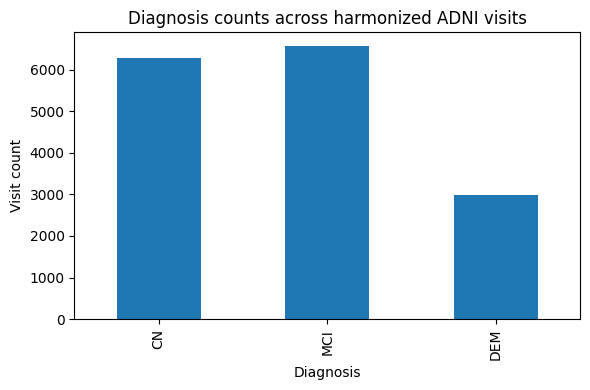

Caption: This shows the distribution of diagnosis states across all available ADNI visits after harmonization.


In [6]:
dx_counts = dx["dx"].value_counts().reindex(["CN", "MCI", "DEM"]).dropna()

plt.figure(figsize=(6, 4))
dx_counts.plot(kind="bar")
plt.title("Diagnosis counts across harmonized ADNI visits")
plt.xlabel("Diagnosis")
plt.ylabel("Visit count")
plt.tight_layout()
plt.savefig(FIG_DIR / "diagnosis_counts.png", dpi=200)
plt.show()

show_caption("This shows the distribution of diagnosis states across all available ADNI visits after harmonization.")

# 4. Primary outcome: 2-year MCI-to-dementia conversion

This creates the main classification target:

- `0 = stable MCI`
- `1 = converted to dementia within 2 years`

The index visit is the first eligible MCI visit for each participant.

In [12]:
def build_mci_conversion_cohort(dx, window_months=24):
    rows = []

    for rid, g in dx.groupby("RID"):
        g = g.copy()

        if g["visit_month"].notna().any():
            g = g.sort_values("visit_month")
        else:
            g = g.sort_values("exam_date")

        g = g.reset_index(drop=True)

        mci_visits = g[g["dx"] == "MCI"].copy()
        if mci_visits.empty:
            continue

        index_row = mci_visits.iloc[0]
        index_month = index_row.get("visit_month", np.nan)
        index_date = index_row.get("exam_date", pd.NaT)

        if pd.notna(index_month):
            after = g[g["visit_month"] > index_month].copy()
            after["months_after_index"] = after["visit_month"] - index_month
        elif pd.notna(index_date):
            after = g[g["exam_date"] > index_date].copy()
            after["months_after_index"] = (after["exam_date"] - index_date).dt.days / 30.44
        else:
            continue

        if after.empty:
            continue

        max_follow = after["months_after_index"].max()
        window = after[(after["months_after_index"] > 0) & (after["months_after_index"] <= window_months)]

        converted_within_window = (window["dx"] == "DEM").any()

        # Hybrid rule:
        # - keep all known converters within 24 months
        # - keep stable cases only if they have at least 24 months of follow-up
        if converted_within_window:
            y = 1
        elif pd.notna(max_follow) and max_follow >= window_months:
            y = 0
        else:
            continue

        rows.append({
            "RID": rid,
            "index_VISCODE": index_row.get("VISCODE", np.nan),
            "index_VISCODE2": index_row.get("VISCODE2", np.nan),
            "index_month": index_month,
            "index_exam_date": index_date,
            "y_convert_2yr": y,
            "max_followup_after_index": max_follow,
            "n_followup_visits": len(after),
            "n_window_visits": len(window),
        })

    out = pd.DataFrame(rows)
    if not out.empty:
        out = out.drop_duplicates(subset=["RID"]).reset_index(drop=True)

    return out


index_cohort = build_mci_conversion_cohort(dx, window_months=24)
print("MCI conversion cohort:", index_cohort.shape)
print(index_cohort["y_convert_2yr"].value_counts(dropna=False))
display(index_cohort.head())

index_cohort.to_csv(OUTPUT_DIR / "primary_mci_conversion_cohort.csv", index=False)

MCI conversion cohort: (1004, 9)
y_convert_2yr
0    743
1    261
Name: count, dtype: int64


,RID,index_VISCODE,index_VISCODE2,index_month,index_exam_date,y_convert_2yr,max_followup_after_index,n_followup_visits,n_window_visits
0,2,v11,m84,84.0,2012-10-04,0,60.0,4,1
1,4,bl,bl,0.0,2005-11-08,0,36.0,4,3
2,6,bl,bl,0.0,2005-12-01,0,36.0,5,4
3,30,bl,bl,0.0,2005-10-20,1,36.0,5,4
4,33,bl,bl,0.0,2005-12-09,0,36.0,5,4


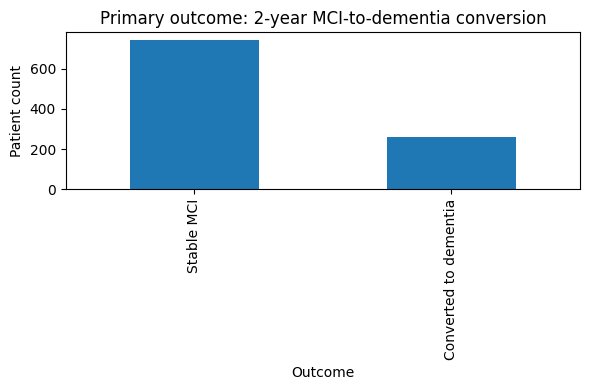

Caption: This is the primary binary outcome used for the stepwise classification models.


In [13]:
target_counts = index_cohort["y_convert_2yr"].map({
    0: "Stable MCI",
    1: "Converted to dementia"
}).value_counts()

plt.figure(figsize=(6, 4))
target_counts.plot(kind="bar")
plt.title("Primary outcome: 2-year MCI-to-dementia conversion")
plt.xlabel("Outcome")
plt.ylabel("Patient count")
plt.tight_layout()
plt.savefig(FIG_DIR / "target_distribution.png", dpi=200)
plt.show()

show_caption("This is the primary binary outcome used for the stepwise classification models.")

# 5. Secondary outcomes: 2-year cognitive score change

This section creates continuous progression targets:

- `MMSE_change_2yr`
- `MOCA_change_2yr`
- `CDRSB_change_2yr`

The notebook finds the baseline score near the index MCI visit and the closest score around 24 months, using an 18–30 month follow-up window.

In [14]:
def find_score_column(df, preferred_names, contains_any=None):
    if df is None:
        return None

    for c in preferred_names:
        if c in df.columns:
            return c

    if contains_any:
        for c in df.columns:
            cu = c.upper()
            if any(term.upper() in cu for term in contains_any):
                return c

    return None


def prepare_visit_score_table(df, table_name, score_col):
    if df is None or score_col is None:
        print(f"Skipping {table_name}: missing table or score column")
        return None

    d = df.copy()

    if "VISCODE2" not in d.columns and "VISCODE" in d.columns:
        d["VISCODE2"] = d["VISCODE"]
    if "VISCODE" not in d.columns and "VISCODE2" in d.columns:
        d["VISCODE"] = d["VISCODE2"]

    date_col = get_examdate_col(d)
    if date_col is not None:
        d["score_exam_date"] = pd.to_datetime(d[date_col], errors="coerce")
    else:
        d["score_exam_date"] = pd.NaT

    if "VISCODE2" in d.columns:
        d["score_month"] = d["VISCODE2"].apply(infer_month_from_visit)
    elif "VISCODE" in d.columns:
        d["score_month"] = d["VISCODE"].apply(infer_month_from_visit)
    else:
        d["score_month"] = np.nan

    keep = ["RID", "VISCODE", "VISCODE2", "score_month", "score_exam_date", score_col]
    d = d[[c for c in keep if c in d.columns]].copy()
    d = d.rename(columns={score_col: "score"})
    d["score"] = pd.to_numeric(d["score"], errors="coerce")
    d = d.dropna(subset=["RID", "score"])
    d["RID"] = d["RID"].astype(int)

    print(f"{table_name} score table:", d.shape, "| score_col:", score_col)
    return d


mmse_col = find_score_column(tables.get("MMSE"), ["MMSCORE", "MMSE", "MMSCORE_TOTAL"], ["MMSE", "MMSCORE"])
moca_col = find_score_column(tables.get("MOCA"), ["MOCA", "MOCATOTS", "MOCASCORE", "MOCATOTAL"], ["MOCA"])
cdr_col = find_score_column(tables.get("CDR"), ["CDRSB", "CDRSUM", "CDSOB", "CDGLOBAL"], ["CDRSB", "SUM", "BOX"])

print("MMSE column:", mmse_col)
print("MOCA column:", moca_col)
print("CDR-SB column:", cdr_col)

mmse_scores = prepare_visit_score_table(tables.get("MMSE"), "MMSE", mmse_col)
moca_scores = prepare_visit_score_table(tables.get("MOCA"), "MOCA", moca_col)
cdr_scores = prepare_visit_score_table(tables.get("CDR"), "CDR", cdr_col)

MMSE column: MMSCORE
MOCA column: MOCA
CDR-SB column: CDRSB
MMSE score table: (14438, 6) | score_col: MMSCORE
MOCA score table: (3706, 6) | score_col: MOCA
CDR score table: (14372, 6) | score_col: CDRSB


In [16]:
def attach_2yr_change(index_df, score_df, outcome_prefix, target_month=24, window_low=18, window_high=30):
    if score_df is None or index_df.empty:
        return pd.DataFrame()

    rows = []

    for _, idx in index_df.iterrows():
        rid = idx["RID"]
        patient_scores = score_df[score_df["RID"] == rid].copy()
        if patient_scores.empty:
            continue

        idx_month = idx.get("index_month", np.nan)
        idx_date = idx.get("index_exam_date", pd.NaT)

        if pd.notna(idx_month) and patient_scores["score_month"].notna().any():
            patient_scores["months_after_index"] = patient_scores["score_month"] - idx_month
        elif pd.notna(idx_date) and patient_scores["score_exam_date"].notna().any():
            patient_scores["months_after_index"] = (patient_scores["score_exam_date"] - idx_date).dt.days / 30.44
        else:
            continue

        baseline_candidates = patient_scores[
            patient_scores["months_after_index"].between(-3, 3, inclusive="both")
        ].copy()

        if baseline_candidates.empty:
            patient_scores["abs_index_distance"] = patient_scores["months_after_index"].abs()
            baseline_candidates = patient_scores.sort_values("abs_index_distance").head(1).copy()

        baseline_row = baseline_candidates.iloc[
            baseline_candidates["months_after_index"].abs().argmin()
        ]
        baseline_score = baseline_row["score"]

        follow_candidates = patient_scores[
            patient_scores["months_after_index"].between(window_low, window_high, inclusive="both")
        ].copy()

        if follow_candidates.empty:
            continue

        follow_candidates["abs_target_distance"] = (follow_candidates["months_after_index"] - target_month).abs()
        follow_row = follow_candidates.sort_values("abs_target_distance").iloc[0]
        follow_score = follow_row["score"]

        rows.append({
            "RID": rid,
            f"{outcome_prefix}_baseline": baseline_score,
            f"{outcome_prefix}_2yr": follow_score,
            f"{outcome_prefix}_change_2yr": follow_score - baseline_score,
            f"{outcome_prefix}_months_to_followup": follow_row["months_after_index"],
        })

    return pd.DataFrame(rows)


mmse_change = attach_2yr_change(index_cohort, mmse_scores, "MMSE")
moca_change = attach_2yr_change(index_cohort, moca_scores, "MOCA")
cdr_change = attach_2yr_change(index_cohort, cdr_scores, "CDRSB")

for name, df_change, col in [
    ("MMSE", mmse_change, "MMSE_change_2yr"),
    ("MOCA", moca_change, "MOCA_change_2yr"),
    ("CDRSB", cdr_change, "CDRSB_change_2yr"),
]:
    print("\n", name, "2-year change rows:", df_change.shape)
    if not df_change.empty:
        print(df_change[col].describe())
        display(df_change.head())

mmse_change.to_csv(OUTPUT_DIR / "mmse_2yr_change.csv", index=False)
moca_change.to_csv(OUTPUT_DIR / "moca_2yr_change.csv", index=False)
cdr_change.to_csv(OUTPUT_DIR / "cdrsb_2yr_change.csv", index=False)


 MMSE 2-year change rows: (892, 5)
count    892.000000
mean      -1.254484
std        3.027230
min      -19.000000
25%       -3.000000
50%       -1.000000
75%        1.000000
max        6.000000
Name: MMSE_change_2yr, dtype: float64


,RID,MMSE_baseline,MMSE_2yr,MMSE_change_2yr,MMSE_months_to_followup
0,2,24.0,28.0,4.0,24.0
1,4,27.0,27.0,0.0,18.0
2,6,25.0,26.0,1.0,24.0
3,30,29.0,22.0,-7.0,24.0
4,33,29.0,25.0,-4.0,24.0



 MOCA 2-year change rows: (136, 5)
count    136.000000
mean      -0.669118
std        3.028397
min      -10.000000
25%       -2.000000
50%        0.000000
75%        1.000000
max        6.000000
Name: MOCA_change_2yr, dtype: float64


,RID,MOCA_baseline,MOCA_2yr,MOCA_change_2yr,MOCA_months_to_followup
0,896,25.0,25.0,0.0,30.0
1,1261,22.0,23.0,1.0,24.0
2,4076,25.0,24.0,-1.0,30.0
3,4100,22.0,22.0,0.0,24.0
4,4278,16.0,18.0,2.0,30.0



 CDRSB 2-year change rows: (898, 5)
count    898.000000
mean       0.937082
std        1.834786
min       -3.000000
25%        0.000000
50%        0.500000
75%        1.500000
max       11.500000
Name: CDRSB_change_2yr, dtype: float64


,RID,CDRSB_baseline,CDRSB_2yr,CDRSB_change_2yr,CDRSB_months_to_followup
0,2,1.0,0.0,-1.0,24.0
1,4,1.0,1.0,0.0,18.0
2,6,0.5,2.0,1.5,24.0
3,30,1.0,7.0,6.0,24.0
4,33,2.0,5.5,3.5,24.0


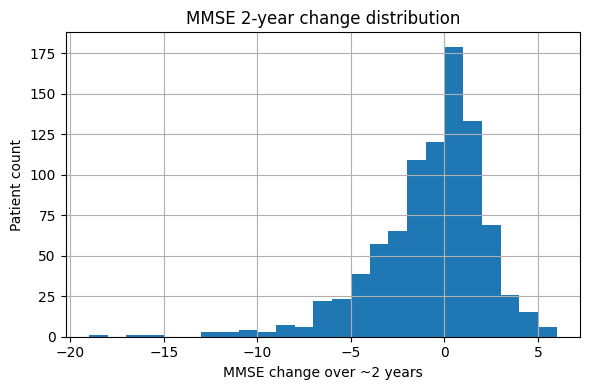

Caption: This distribution shows how much MMSE changed over approximately 2 years.


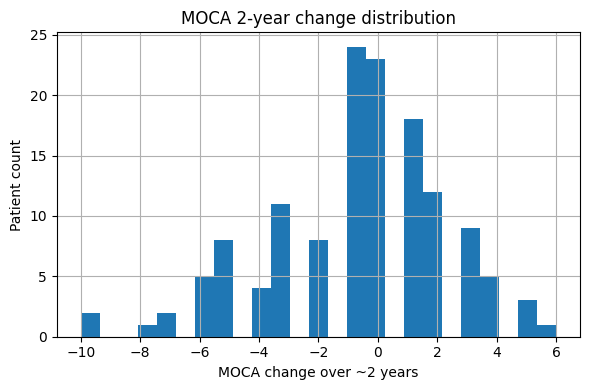

Caption: This distribution shows how much MOCA changed over approximately 2 years.


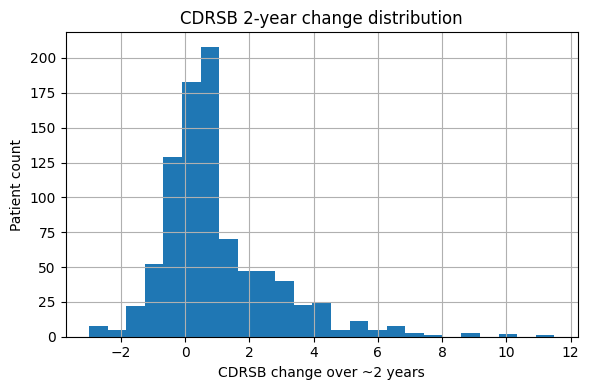

Caption: This distribution shows how much CDRSB changed over approximately 2 years.


In [17]:
for name, df_change, col in [
    ("MMSE", mmse_change, "MMSE_change_2yr"),
    ("MOCA", moca_change, "MOCA_change_2yr"),
    ("CDRSB", cdr_change, "CDRSB_change_2yr"),
]:
    if df_change.empty or col not in df_change.columns:
        print(f"Skipping {name} histogram: no data")
        continue

    plt.figure(figsize=(6, 4))
    df_change[col].dropna().hist(bins=25)
    plt.title(f"{name} 2-year change distribution")
    plt.xlabel(f"{name} change over ~2 years")
    plt.ylabel("Patient count")
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"{name.lower()}_change_distribution.png", dpi=200)
    plt.show()

    show_caption(f"This distribution shows how much {name} changed over approximately 2 years.")

# 6. Merge baseline/index features

This creates a single baseline row per index MCI patient and merges the available phenotyping layers.

Every merge prints before/after shapes to prevent silent row duplication.

In [20]:
def normalize_visit_columns(df):
    d = df.copy()

    if "VISCODE2" not in d.columns and "VISCODE" in d.columns:
        d["VISCODE2"] = d["VISCODE"]
    if "VISCODE" not in d.columns and "VISCODE2" in d.columns:
        d["VISCODE"] = d["VISCODE2"]

    if "VISCODE2" in d.columns:
        d["merge_month"] = d["VISCODE2"].apply(infer_month_from_visit)
    elif "VISCODE" in d.columns:
        d["merge_month"] = d["VISCODE"].apply(infer_month_from_visit)
    else:
        d["merge_month"] = np.nan

    date_col = get_examdate_col(d)
    if date_col is not None:
        d["merge_exam_date"] = pd.to_datetime(d[date_col], errors="coerce")
    else:
        d["merge_exam_date"] = pd.NaT

    return d


def clean_merge_artifacts(df):
    """
    Removes duplicate visit/suffix columns created by repeated pandas merges.
    Keeps the intentional index visit columns.
    """
    keep_always = {
        "RID",
        "index_VISCODE",
        "index_VISCODE2",
        "index_month",
        "index_exam_date",
        "y_convert_2yr",
        "max_followup_after_index",
        "n_followup_visits",
        "n_window_visits",
    }

    drop_cols = []

    for c in df.columns:
        if c in keep_always:
            continue

        # Drop raw visit columns from right-side merges
        if c in ["VISCODE", "VISCODE2", "merge_month", "merge_exam_date"]:
            drop_cols.append(c)

        # Drop pandas merge suffix artifacts
        if c.endswith("_x") or c.endswith("_y"):
            if c not in keep_always:
                drop_cols.append(c)

    drop_cols = sorted(set(drop_cols))
    if drop_cols:
        df = df.drop(columns=drop_cols, errors="ignore")

    # Remove truly duplicate column names if they exist
    df = df.loc[:, ~df.columns.duplicated()].copy()

    return df


def safe_prefix_cols(df, prefix, exclude=("RID", "VISCODE", "VISCODE2", "merge_month", "merge_exam_date")):
    rename = {}
    for c in df.columns:
        if c not in exclude and not c.startswith(prefix + "__"):
            rename[c] = f"{prefix}__{c}"
    return df.rename(columns=rename)


def merge_exact_visit(base, table, table_name, prefix=None):
    if table is None:
        print(f"SKIP merge {table_name}: table missing")
        return clean_merge_artifacts(base)

    if "RID" not in table.columns:
        print(f"SKIP merge {table_name}: no RID")
        return clean_merge_artifacts(base)

    prefix = prefix or table_name
    before = base.shape

    base = clean_merge_artifacts(base)

    t = normalize_visit_columns(table)
    t["RID"] = pd.to_numeric(t["RID"], errors="coerce")
    t = t.dropna(subset=["RID"]).copy()
    t["RID"] = t["RID"].astype(int)

    if "index_VISCODE2" in base.columns and "VISCODE2" in t.columns:
        right = t.drop_duplicates(subset=["RID", "VISCODE2"], keep="first").copy()
        right = safe_prefix_cols(right, prefix)

        # Prevent unprefixed visit columns from entering the model dataframe
        right = right.drop(columns=["VISCODE", "merge_month", "merge_exam_date"], errors="ignore")

        merged = base.merge(
            right,
            left_on=["RID", "index_VISCODE2"],
            right_on=["RID", "VISCODE2"],
            how="left",
            suffixes=("", f"_{prefix}_drop")
        )

    elif "index_VISCODE" in base.columns and "VISCODE" in t.columns:
        right = t.drop_duplicates(subset=["RID", "VISCODE"], keep="first").copy()
        right = safe_prefix_cols(right, prefix)

        # Prevent unprefixed visit columns from entering the model dataframe
        right = right.drop(columns=["VISCODE2", "merge_month", "merge_exam_date"], errors="ignore")

        merged = base.merge(
            right,
            left_on=["RID", "index_VISCODE"],
            right_on=["RID", "VISCODE"],
            how="left",
            suffixes=("", f"_{prefix}_drop")
        )

    else:
        print(f"SKIP merge {table_name}: no compatible visit columns")
        return clean_merge_artifacts(base)

    # Drop any temporary duplicate columns created during merge
    temp_drop_cols = [c for c in merged.columns if c.endswith(f"_{prefix}_drop")]
    if temp_drop_cols:
        merged = merged.drop(columns=temp_drop_cols, errors="ignore")

    merged = clean_merge_artifacts(merged)
    merged = merged.drop_duplicates(subset=["RID"], keep="first").reset_index(drop=True)

    print(f"Merged {table_name}: {before} -> {merged.shape}")
    return merged


def merge_by_rid_only(base, table, table_name, prefix=None):
    if table is None:
        print(f"SKIP merge {table_name}: table missing")
        return clean_merge_artifacts(base)

    if "RID" not in table.columns:
        print(f"SKIP merge {table_name}: no RID")
        return clean_merge_artifacts(base)

    prefix = prefix or table_name
    before = base.shape

    base = clean_merge_artifacts(base)

    t = table.copy()
    t["RID"] = pd.to_numeric(t["RID"], errors="coerce")
    t = t.dropna(subset=["RID"]).copy()
    t["RID"] = t["RID"].astype(int)
    t = t.drop_duplicates(subset=["RID"], keep="first")
    t = safe_prefix_cols(t, prefix, exclude=("RID",))

    merged = base.merge(
        t,
        on="RID",
        how="left",
        suffixes=("", f"_{prefix}_drop")
    )

    temp_drop_cols = [c for c in merged.columns if c.endswith(f"_{prefix}_drop")]
    if temp_drop_cols:
        merged = merged.drop(columns=temp_drop_cols, errors="ignore")

    merged = clean_merge_artifacts(merged)
    merged = merged.drop_duplicates(subset=["RID"], keep="first").reset_index(drop=True)

    print(f"Merged {table_name} by RID: {before} -> {merged.shape}")
    return merged

In [21]:
analysis_df = index_cohort.copy()
print("Starting analysis_df:", analysis_df.shape)

# Demographics and simple screens
analysis_df = merge_exact_visit(analysis_df, tables.get("PTDEMOG"), "PTDEMOG")
analysis_df = merge_exact_visit(analysis_df, tables.get("MMSE"), "MMSE")
analysis_df = merge_exact_visit(analysis_df, tables.get("MOCA"), "MOCA")
analysis_df = merge_exact_visit(analysis_df, tables.get("CDR"), "CDR")

# Basic clinical and broad cognitive
analysis_df = merge_exact_visit(analysis_df, tables.get("GDSCALE"), "GDSCALE")
analysis_df = merge_exact_visit(analysis_df, tables.get("NEUROBAT"), "NEUROBAT")
analysis_df = merge_exact_visit(analysis_df, tables.get("UWNPSYCHSUM"), "UWNPSYCHSUM")
analysis_df = merge_exact_visit(analysis_df, tables.get("FAQ"), "FAQ")
analysis_df = merge_exact_visit(analysis_df, tables.get("ADAS"), "ADAS")

# APOE / genetics
analysis_df = merge_by_rid_only(analysis_df, tables.get("APOERES"), "APOERES")

# MRI
analysis_df = merge_exact_visit(analysis_df, tables.get("UCSFFSX6"), "UCSFFSX6")
analysis_df = merge_exact_visit(analysis_df, tables.get("UCSFFSX7"), "UCSFFSX7")

# Biomarkers
for biomarker_name in [
    "BIOMARK",
    "UPENNBIOMK_MASTER",
    "UPENNBIOMK_ROCHE_ELECSYS",
    "UPENNPLASMA",
    "C2N_PRECIVITYAD2_PLASMA",
    "FUJIREBIOABETA",
    "FUJIREBIOABETAPLASMA",
    "UGOTPTAU181",
]:
    analysis_df = merge_exact_visit(analysis_df, tables.get(biomarker_name), biomarker_name)

print("Final analysis_df:", analysis_df.shape)
print("Rows:", len(analysis_df))
print("Unique RIDs:", analysis_df["RID"].nunique())
print("Duplicate RIDs:", analysis_df["RID"].duplicated().sum())

display(analysis_df.head())
analysis_df.to_csv(OUTPUT_DIR / "stepwise_modeling_dataset.csv", index=False)

Starting analysis_df: (1004, 9)
Merged PTDEMOG: (1004, 9) -> (1004, 91)
Merged MMSE: (1004, 91) -> (1004, 147)
Merged MOCA: (1004, 147) -> (1004, 203)
Merged CDR: (1004, 203) -> (1004, 226)
Merged GDSCALE: (1004, 226) -> (1004, 256)
Merged NEUROBAT: (1004, 256) -> (1004, 337)
Merged UWNPSYCHSUM: (1004, 337) -> (1004, 346)
Merged FAQ: (1004, 346) -> (1004, 371)
Merged ADAS: (1004, 371) -> (1004, 385)
Merged APOERES by RID: (1004, 385) -> (1004, 401)
Merged UCSFFSX6: (1004, 401) -> (1004, 745)
Merged UCSFFSX7: (1004, 745) -> (1004, 1090)
Merged BIOMARK: (1004, 1090) -> (1004, 1153)
Merged UPENNBIOMK_MASTER: (1004, 1153) -> (1004, 1166)
Merged UPENNBIOMK_ROCHE_ELECSYS: (1004, 1166) -> (1004, 1178)
Merged UPENNPLASMA: (1004, 1178) -> (1004, 1182)
Merged C2N_PRECIVITYAD2_PLASMA: (1004, 1182) -> (1004, 1198)
Merged FUJIREBIOABETA: (1004, 1198) -> (1004, 1215)
Merged FUJIREBIOABETAPLASMA: (1004, 1215) -> (1004, 1223)
Merged UGOTPTAU181: (1004, 1223) -> (1004, 1229)
Final analysis_df: (1004, 1

,RID,index_VISCODE,index_VISCODE2,index_month,index_exam_date,y_convert_2yr,max_followup_after_index,n_followup_visits,n_window_visits,PTDEMOG__ORIGPROT,PTDEMOG__COLPROT,PTDEMOG__PTID,PTDEMOG__VISDATE,PTDEMOG__PTSOURCE,PTDEMOG__PTGENDER,PTDEMOG__PTDOB,PTDEMOG__PTDOBYY,PTDEMOG__PTHAND,PTDEMOG__PTMARRY,PTDEMOG__PTEDUCAT,PTDEMOG__PTWORKHS,PTDEMOG__PTWORK,PTDEMOG__PTNOTRT,PTDEMOG__PTRTYR,PTDEMOG__PTHOME,PTDEMOG__PTTLANG,PTDEMOG__PTPLANG,PTDEMOG__PTADBEG,PTDEMOG__PTCOGBEG,PTDEMOG__PTADDX,PTDEMOG__PTETHCAT,PTDEMOG__PTRACCAT,PTDEMOG__PTIDENT,PTDEMOG__PTORIENT,PTDEMOG__PTORIENTOT,PTDEMOG__PTENGSPK,PTDEMOG__PTNLANG,PTDEMOG__PTENGSPKAGE,PTDEMOG__PTCLANG,PTDEMOG__PTLANGSP,PTDEMOG__PTLANGWR,PTDEMOG__PTSPTIM,PTDEMOG__PTSPOTTIM,PTDEMOG__PTLANGPR1,PTDEMOG__PTLANGSP1,PTDEMOG__PTLANGRD1,PTDEMOG__PTLANGWR1,PTDEMOG__PTLANGUN1,PTDEMOG__PTLANGPR2,PTDEMOG__PTLANGSP2,PTDEMOG__PTLANGRD2,PTDEMOG__PTLANGWR2,PTDEMOG__PTLANGUN2,PTDEMOG__PTLANGPR3,PTDEMOG__PTLANGSP3,PTDEMOG__PTLANGRD3,PTDEMOG__PTLANGWR3,PTDEMOG__PTLANGUN3,PTDEMOG__PTLANGPR4,PTDEMOG__PTLANGSP4,PTDEMOG__PTLANGRD4,PTDEMOG__PTLANGWR4,PTDEMOG__PTLANGUN4,PTDEMOG__PTLANGPR5,PTDEMOG__PTLANGSP5,PTDEMOG__PTLANGRD5,PTDEMOG__PTLANGWR5,PTDEMOG__PTLANGUN5,PTDEMOG__PTLANGPR6,PTDEMOG__PTLANGSP6,PTDEMOG__PTLANGRD6,PTDEMOG__PTLANGWR6,PTDEMOG__PTLANGUN6,PTDEMOG__PTLANGTTL,PTDEMOG__PTETHCATH,PTDEMOG__PTASIAN,PTDEMOG__PTOPI,PTDEMOG__PTBORN,PTDEMOG__PTBIRPL,PTDEMOG__PTIMMAGE,...,BIOMARK__DD_CRF_VERSION_LABEL,BIOMARK__LANGUAGE_CODE,BIOMARK__HAS_QC_ERROR,BIOMARK__update_stamp,UPENNBIOMK_MASTER__ORIGPROT,UPENNBIOMK_MASTER__BATCH,UPENNBIOMK_MASTER__KIT,UPENNBIOMK_MASTER__STDS,UPENNBIOMK_MASTER__DRAWDTE,UPENNBIOMK_MASTER__RUNDATE,UPENNBIOMK_MASTER__ABETA,UPENNBIOMK_MASTER__TAU,UPENNBIOMK_MASTER__PTAU,UPENNBIOMK_MASTER__ABETA_RAW,UPENNBIOMK_MASTER__TAU_RAW,UPENNBIOMK_MASTER__PTAU_RAW,UPENNBIOMK_MASTER__update_stamp,UPENNBIOMK_ROCHE_ELECSYS__ORIGPROT,UPENNBIOMK_ROCHE_ELECSYS__COLPROT,UPENNBIOMK_ROCHE_ELECSYS__PTID,UPENNBIOMK_ROCHE_ELECSYS__EXAMDATE,UPENNBIOMK_ROCHE_ELECSYS__BATCH,UPENNBIOMK_ROCHE_ELECSYS__RUNDATE,UPENNBIOMK_ROCHE_ELECSYS__ABETA40,UPENNBIOMK_ROCHE_ELECSYS__ABETA42,UPENNBIOMK_ROCHE_ELECSYS__TAU,UPENNBIOMK_ROCHE_ELECSYS__PTAU,UPENNBIOMK_ROCHE_ELECSYS__COMMENT,UPENNBIOMK_ROCHE_ELECSYS__update_stamp,UPENNPLASMA__ORIGPROT,UPENNPLASMA__AB40,UPENNPLASMA__AB42,UPENNPLASMA__update_stamp,C2N_PRECIVITYAD2_PLASMA__ORIGPROT,C2N_PRECIVITYAD2_PLASMA__COLPROT,C2N_PRECIVITYAD2_PLASMA__PTID,C2N_PRECIVITYAD2_PLASMA__EXAMDATE,C2N_PRECIVITYAD2_PLASMA__Primary,C2N_PRECIVITYAD2_PLASMA__Additive,C2N_PRECIVITYAD2_PLASMA__pT217_C2N,C2N_PRECIVITYAD2_PLASMA__npT217_C2N,C2N_PRECIVITYAD2_PLASMA__AB42_C2N,C2N_PRECIVITYAD2_PLASMA__AB40_C2N,C2N_PRECIVITYAD2_PLASMA__AB42_AB40_C2N,C2N_PRECIVITYAD2_PLASMA__pT217_npT217_C2N,C2N_PRECIVITYAD2_PLASMA__APS2_C2N,C2N_PRECIVITYAD2_PLASMA__APOE_C2N,C2N_PRECIVITYAD2_PLASMA__Comments,C2N_PRECIVITYAD2_PLASMA__update_stamp,FUJIREBIOABETA__ORIGPROT,FUJIREBIOABETA__EXAMDATE,FUJIREBIOABETA__GUSPECID,FUJIREBIOABETA__VID,FUJIREBIOABETA__DRAWDTE,FUJIREBIOABETA__DER,FUJIREBIOABETA__SITE,FUJIREBIOABETA__VOL,FUJIREBIOABETA__RECDTE,FUJIREBIOABETA__STORDTE,FUJIREBIOABETA__RUN,FUJIREBIOABETA__RUNDATE,FUJIREBIOABETA__ABETA42,FUJIREBIOABETA__ABETA40,FUJIREBIOABETA__ABETA42_40,FUJIREBIOABETA__COMMENTS,FUJIREBIOABETA__update_stamp,FUJIREBIOABETAPLASMA__ORIGPROT,FUJIREBIOABETAPLASMA__EXAMDATE,FUJIREBIOABETAPLASMA__SPECIMEN_TYPE,FUJIREBIOABETAPLASMA__ANALYTE,FUJIREBIOABETAPLASMA__COUNT,FUJIREBIOABETAPLASMA__CONCENTRATION,FUJIREBIOABETAPLASMA__MM_NUMBER,FUJIREBIOABETAPLASMA__update_stamp,UGOTPTAU181__ORIGPROT,UGOTPTAU181__EXAMDATE,UGOTPTAU181__VID,UGOTPTAU181__PLASMAPTAU181,UGOTPTAU181__COMMENT,UGOTPTAU181__update_stamp
0,2,v11,m84,84.0,2012-10-04,0,60.0,4,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

# 7. Feature grouping and leakage policy

This notebook intentionally uses MMSE/MoCA/CDR in specific stepwise models because the question is about how much phenotyping is necessary. However, a separate broad cognitive model excludes MMSE/MoCA/CDR to provide a less diagnosis-adjacent comparison.

In [24]:
TARGET_COL = "y_convert_2yr"

ID_COLS = {
    "RID", "index_VISCODE", "index_VISCODE2", "index_month", "index_exam_date",
    "y_convert_2yr", "max_followup_after_index", "n_followup_visits", "n_window_visits",
}

LEAKY_CONTAINS = ["DX", "DIAG", "CONVERT", "DEMENTIA", "FOLLOWUP", "FUTURE", "STATUS"]

METADATA_CONTAINS = [
    "ORIGPROT", "COLPROT", "USERDATE", "UPDATE", "STAMP", "VISDATE", "EXAMDATE",
    "RUNDATE", "COLDATE", "VERSION", "LANGUAGE", "QC", "ERROR", "PHASE",
    "VISCODE", "SITE", "PTID", "RECNO",
]

METADATA_ENDS = ["__ID", "__RID", "__SITEID"]


def is_metadata_or_leaky(col):
    cu = col.upper()

    if col in ID_COLS:
        return True

    if any(cu.endswith(x.upper()) for x in METADATA_ENDS):
        return True

    if any(term in cu for term in METADATA_CONTAINS):
        return True

    if any(term in cu for term in LEAKY_CONTAINS):
        return True

    return False


def unique_keep_order(cols):
    seen = set()
    out = []
    for c in cols:
        if c not in seen:
            seen.add(c)
            out.append(c)
    return out


analysis_model = analysis_df.copy()

# Demographics
demo_patterns = ["PTGENDER", "PTSEX", "SEX", "PTEDUCAT", "EDUC", "PTHAND", "PTMARRY", "PTETHCAT", "PTRACCAT", "AGE"]

demo_cols = [
    c for c in analysis_model.columns
    if c.startswith("PTDEMOG__")
    and not is_metadata_or_leaky(c)
    and any(p in c.upper() for p in demo_patterns)
]

age_cols = [c for c in analysis_model.columns if c.upper().endswith("__AGE") or c.upper() == "AGE"]
for c in age_cols:
    if c not in demo_cols and not is_metadata_or_leaky(c):
        demo_cols.append(c)

# Basic clinical
basic_clinical_cols = [
    c for c in analysis_model.columns
    if c.startswith("GDSCALE__")
    and not is_metadata_or_leaky(c)
    and ("GDTOTAL" in c.upper() or c.upper().startswith("GDSCALE__GD"))
]

# Simple cognitive screens
mmse_cols = [
    c for c in analysis_model.columns
    if c.startswith("MMSE__")
    and "MMSCORE" in c.upper()
    and not is_metadata_or_leaky(c)
]

moca_cols = [
    c for c in analysis_model.columns
    if c.startswith("MOCA__")
    and not is_metadata_or_leaky(c)
    and "MOCA" in c.upper()
]

cdr_cols = [
    c for c in analysis_model.columns
    if c.startswith("CDR__")
    and not is_metadata_or_leaky(c)
    and any(term in c.upper() for term in ["CDRSB", "CDGLOBAL", "CDSUM", "BOX"])
]

# Broad cognitive battery, excluding MMSE/MOCA/CDR
cog_patterns = [
    "RAVLT", "AVTOT", "AVERR", "AVDEL",
    "LIMM", "LDELTOTAL", "LDELCUE", "LM",
    "TRAB", "TRAA", "TRAIL",
    "DIGIT", "CLOCK", "COPY",
    "BOSTON", "ANART", "CATANIMSC",
    "ADNI_MEM", "ADNI_EF", "ADNI_LAN", "ADNI_VS",
]

broad_cog_cols = [
    c for c in analysis_model.columns
    if c.startswith(("NEUROBAT__", "UWNPSYCHSUM__"))
    and not is_metadata_or_leaky(c)
    and any(p in c.upper() for p in cog_patterns)
]

# APOE
genetic_raw_cols = [
    c for c in analysis_model.columns
    if c.startswith("APOERES__")
    and not is_metadata_or_leaky(c)
    and ("GENOTYPE" in c.upper() or "APOE" in c.upper())
]

def apoe4_count(x):
    if pd.isna(x):
        return np.nan
    return str(x).upper().count("4")

apoe_genotype_candidates = [c for c in genetic_raw_cols if "GENOTYPE" in c.upper()]
if apoe_genotype_candidates:
    genotype_col = apoe_genotype_candidates[0]
    analysis_model["APOE4_count"] = analysis_model[genotype_col].apply(apoe4_count)
    apoe_cols = ["APOE4_count"]
else:
    apoe_cols = genetic_raw_cols

# MRI
bad_mri_terms = ["IMAGEUID", "EXAMDATE", "RUNDATE", "STATUS", "OVERALLQC", "TEMPQC", "FRONTQC", "PARQC", "INSULAQC"]

mri_cols = [
    c for c in analysis_model.columns
    if c.startswith(("UCSFFSX6__", "UCSFFSX7__"))
    and not is_metadata_or_leaky(c)
    and not any(bad in c.upper() for bad in bad_mri_terms)
]

# Biomarkers
biomarker_prefixes = (
    "BIOMARK__", "UPENNBIOMK_MASTER__", "UPENNBIOMK_ROCHE_ELECSYS__",
    "UPENNPLASMA__", "C2N_PRECIVITYAD2_PLASMA__", "FUJIREBIOABETA__",
    "FUJIREBIOABETAPLASMA__", "UGOTPTAU181__"
)

biomarker_terms = [
    "ABETA", "ABETA42", "ABETA40", "PTAU", "TAU", "NFL", "GFAP", "AMYLOID", "ELECSYS", "PRECIVITY"
]

bad_biomarker_terms = [
    "BATCH", "COMMENT", "COMMENTS", "GUSPECID", "VID", "RUNDATE", "DRAWDTE",
    "EXAMDATE", "ORIGPROT", "COLPROT", "PTID", "UPDATE", "STAMP",
    "SPECIMEN", "SITE", "DER", "RECDTE", "STORDTE", "RUN"
]

biomarker_cols = [
    c for c in analysis_model.columns
    if c.startswith(biomarker_prefixes)
    and not is_metadata_or_leaky(c)
    and any(term in c.upper() for term in biomarker_terms)
    and not any(bad in c.upper() for bad in bad_biomarker_terms)
]

extra_bad_biomarker_cols = [
    "FUJIREBIOABETA__VOL",
    "FUJIREBIOABETAPLASMA__ANALYTE"
]

biomarker_cols = [
    c for c in biomarker_cols
    if c not in extra_bad_biomarker_cols
]

feature_groups = {
    "demographics": unique_keep_order(demo_cols),
    "basic_clinical": unique_keep_order(basic_clinical_cols),
    "mmse": unique_keep_order(mmse_cols),
    "moca": unique_keep_order(moca_cols),
    "cdr": unique_keep_order(cdr_cols),
    "broad_cognitive": unique_keep_order(broad_cog_cols),
    "apoe": unique_keep_order(apoe_cols),
    "mri": unique_keep_order(mri_cols),
    "biomarkers": unique_keep_order(biomarker_cols),
}

for name, cols in feature_groups.items():
    print(f"{name}: {len(cols)}")
    print(cols[:25])
    print()

demographics: 9
['PTDEMOG__PTGENDER', 'PTDEMOG__PTHAND', 'PTDEMOG__PTMARRY', 'PTDEMOG__PTEDUCAT', 'PTDEMOG__PTETHCAT', 'PTDEMOG__PTRACCAT', 'PTDEMOG__PTENGSPKAGE', 'PTDEMOG__PTETHCATH', 'PTDEMOG__PTIMMAGE']

basic_clinical: 17
['GDSCALE__GDUNABL', 'GDSCALE__GDSATIS', 'GDSCALE__GDDROP', 'GDSCALE__GDEMPTY', 'GDSCALE__GDBORED', 'GDSCALE__GDSPIRIT', 'GDSCALE__GDAFRAID', 'GDSCALE__GDHAPPY', 'GDSCALE__GDHELP', 'GDSCALE__GDHOME', 'GDSCALE__GDMEMORY', 'GDSCALE__GDALIVE', 'GDSCALE__GDWORTH', 'GDSCALE__GDENERGY', 'GDSCALE__GDHOPE', 'GDSCALE__GDBETTER', 'GDSCALE__GDTOTAL']

mmse: 1
['MMSE__MMSCORE']

moca: 44
['MOCA__TRAILS', 'MOCA__CUBE', 'MOCA__CLOCKCON', 'MOCA__CLOCKNO', 'MOCA__CLOCKHAN', 'MOCA__LION', 'MOCA__RHINO', 'MOCA__CAMEL', 'MOCA__IMMT1W1', 'MOCA__IMMT1W2', 'MOCA__IMMT1W3', 'MOCA__IMMT1W4', 'MOCA__IMMT1W5', 'MOCA__IMMT2W1', 'MOCA__IMMT2W2', 'MOCA__IMMT2W3', 'MOCA__IMMT2W4', 'MOCA__IMMT2W5', 'MOCA__DIGFOR', 'MOCA__DIGBACK', 'MOCA__LETTERS', 'MOCA__SERIAL1', 'MOCA__SERIAL2', 'MOCA__SERIA

# 8. Stepwise classification models for MCI-to-dementia conversion

This section evaluates the stepwise phenotyping ladder using grouped 5-fold cross-validation. The same patient never appears in both train and test folds.

In [25]:
def valid_cols(cols, df=analysis_model, min_nonmissing=25, min_unique=2):
    out = []
    for c in cols:
        if c not in df.columns:
            continue
        s = df[c]
        if s.notna().sum() < min_nonmissing:
            continue
        if s.dropna().nunique() < min_unique:
            continue
        out.append(c)
    return unique_keep_order(out)


def build_preprocessor(X):
    numeric_cols = X.select_dtypes(include=[np.number, "bool"]).columns.tolist()
    categorical_cols = [c for c in X.columns if c not in numeric_cols]

    transformers = []

    if numeric_cols:
        numeric_transformer = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median", keep_empty_features=True)),
            ("scaler", StandardScaler()),
        ])
        transformers.append(("num", numeric_transformer, numeric_cols))

    if categorical_cols:
        categorical_transformer = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="constant", fill_value="missing", keep_empty_features=True)),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ])
        transformers.append(("cat", categorical_transformer, categorical_cols))

    return ColumnTransformer(transformers=transformers, remainder="drop")


def classifier_models():
    return {
        "logistic_l1": LogisticRegression(
            penalty="l1", solver="liblinear", class_weight="balanced",
            max_iter=5000, random_state=RANDOM_STATE
        ),
        "logistic_l2": LogisticRegression(
            penalty="l2", solver="liblinear", class_weight="balanced",
            max_iter=5000, random_state=RANDOM_STATE
        ),
        "random_forest": RandomForestClassifier(
            n_estimators=300, class_weight="balanced",
            random_state=RANDOM_STATE, n_jobs=-1
        ),
        "extra_trees": ExtraTreesClassifier(
            n_estimators=300, class_weight="balanced",
            random_state=RANDOM_STATE, n_jobs=-1
        ),
    }


def evaluate_classifier_cv(df, features, label, n_splits=5):
    features = valid_cols(features, df=df)
    if not features:
        print(f"SKIP {label}: no valid features")
        return pd.DataFrame()

    X = df[features].copy()
    y = df[TARGET_COL].astype(int)
    groups = df["RID"]

    cv = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    rows = []

    for model_name, model in classifier_models().items():
        print(f"{label} | {model_name} | {len(features)} features")

        for fold, (train_idx, test_idx) in enumerate(cv.split(X, y, groups), start=1):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            pipe = Pipeline(steps=[
                ("preprocess", build_preprocessor(X_train)),
                ("model", model),
            ])

            try:
                pipe.fit(X_train, y_train)
                y_score = pipe.predict_proba(X_test)[:, 1]
                y_pred = (y_score >= 0.5).astype(int)

                tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()
                sensitivity = tp / (tp + fn) if (tp + fn) else np.nan
                specificity = tn / (tn + fp) if (tn + fp) else np.nan
                youden_j = sensitivity + specificity - 1

                rows.append({
                    "feature_set": label,
                    "model": model_name,
                    "fold": fold,
                    "n_features": len(features),
                    "features": " | ".join(features),
                    "roc_auc": roc_auc_score(y_test, y_score),
                    "pr_auc": average_precision_score(y_test, y_score),
                    "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
                    "precision": precision_score(y_test, y_pred, zero_division=0),
                    "sensitivity": sensitivity,
                    "specificity": specificity,
                    "f1": f1_score(y_test, y_pred, zero_division=0),
                    "youden_j": youden_j,
                    "tn": tn, "fp": fp, "fn": fn, "tp": tp,
                })
            except Exception as e:
                print(f"  Fold failed for {label} | {model_name} | fold {fold}: {e}")

    return pd.DataFrame(rows)


def summarize_classification_results(fold_df):
    if fold_df.empty:
        return pd.DataFrame()

    return (
        fold_df
        .groupby(["feature_set", "model"])
        .agg(
            n_features=("n_features", "first"),
            roc_auc_mean=("roc_auc", "mean"),
            roc_auc_sd=("roc_auc", "std"),
            pr_auc_mean=("pr_auc", "mean"),
            balanced_accuracy_mean=("balanced_accuracy", "mean"),
            sensitivity_mean=("sensitivity", "mean"),
            specificity_mean=("specificity", "mean"),
            f1_mean=("f1", "mean"),
            youden_j_mean=("youden_j", "mean"),
        )
        .reset_index()
        .sort_values("roc_auc_mean", ascending=False)
    )

In [26]:
stepwise_feature_sets = {
    "01_demo_only": demo_cols,
    "02_demo_basic_clinical": demo_cols + basic_clinical_cols,
    "03_demo_mmse": demo_cols + mmse_cols,
    "04_demo_moca": demo_cols + moca_cols,
    "05_demo_mmse_moca": demo_cols + mmse_cols + moca_cols,
    "06_demo_cdr_sensitivity": demo_cols + cdr_cols,
    "07_demo_broad_cognitive_no_screens": demo_cols + broad_cog_cols,
    "08_demo_simple_screens_broad_cognitive": demo_cols + mmse_cols + moca_cols + broad_cog_cols,
    "09_cognitive_apoe": demo_cols + mmse_cols + moca_cols + broad_cog_cols + apoe_cols,
    "10_cognitive_apoe_mri": demo_cols + mmse_cols + moca_cols + broad_cog_cols + apoe_cols + mri_cols,
}

if biomarker_cols:
    stepwise_feature_sets["11_cognitive_apoe_biomarkers"] = (
        demo_cols + mmse_cols + moca_cols + broad_cog_cols + apoe_cols + biomarker_cols
    )
    stepwise_feature_sets["12_cognitive_apoe_mri_biomarkers"] = (
        demo_cols + mmse_cols + moca_cols + broad_cog_cols + apoe_cols + mri_cols + biomarker_cols
    )

print("Stepwise feature set sizes:")
for name, cols in stepwise_feature_sets.items():
    print(name, len(valid_cols(cols)))

Stepwise feature set sizes:
01_demo_only 6
02_demo_basic_clinical 22
03_demo_mmse 7
04_demo_moca 49
05_demo_mmse_moca 50
06_demo_cdr_sensitivity 8
07_demo_broad_cognitive_no_screens 56
08_demo_simple_screens_broad_cognitive 100
09_cognitive_apoe 101
10_cognitive_apoe_mri 749
11_cognitive_apoe_biomarkers 114
12_cognitive_apoe_mri_biomarkers 762


In [27]:
classification_results = []

for label, feats in stepwise_feature_sets.items():
    res = evaluate_classifier_cv(analysis_model, feats, label, n_splits=5)
    if not res.empty:
        classification_results.append(res)

classification_fold_results = (
    pd.concat(classification_results, ignore_index=True)
    if classification_results else pd.DataFrame()
)

classification_summary = summarize_classification_results(classification_fold_results)

display(classification_summary)

classification_fold_results.to_csv(OUTPUT_DIR / "stepwise_classification_fold_results.csv", index=False)
classification_summary.to_csv(OUTPUT_DIR / "stepwise_classification_summary.csv", index=False)

01_demo_only | logistic_l1 | 6 features
01_demo_only | logistic_l2 | 6 features
01_demo_only | random_forest | 6 features
01_demo_only | extra_trees | 6 features
02_demo_basic_clinical | logistic_l1 | 22 features
02_demo_basic_clinical | logistic_l2 | 22 features
02_demo_basic_clinical | random_forest | 22 features
02_demo_basic_clinical | extra_trees | 22 features
03_demo_mmse | logistic_l1 | 7 features
03_demo_mmse | logistic_l2 | 7 features
03_demo_mmse | random_forest | 7 features
03_demo_mmse | extra_trees | 7 features
04_demo_moca | logistic_l1 | 49 features
04_demo_moca | logistic_l2 | 49 features
04_demo_moca | random_forest | 49 features
04_demo_moca | extra_trees | 49 features
05_demo_mmse_moca | logistic_l1 | 50 features
05_demo_mmse_moca | logistic_l2 | 50 features
05_demo_mmse_moca | random_forest | 50 features
05_demo_mmse_moca | extra_trees | 50 features
06_demo_cdr_sensitivity | logistic_l1 | 8 features
06_demo_cdr_sensitivity | logistic_l2 | 8 features
06_demo_cdr_sens

,feature_set,model,n_features,roc_auc_mean,roc_auc_sd,pr_auc_mean,balanced_accuracy_mean,sensitivity_mean,specificity_mean,f1_mean,youden_j_mean
47,12_cognitive_apoe_mri_biomarkers,random_forest,762,0.825777,0.026888,0.638319,0.660321,0.394630,0.926011,0.492094,0.320641
39,10_cognitive_apoe_mri,random_forest,749,0.823123,0.038647,0.636929,0.664946,0.398476,0.931417,0.500742,0.329893
43,11_cognitive_apoe_biomarkers,random_forest,114,0.820718,0.029109,0.628689,0.659654,0.394630,0.924678,0.490968,0.319308
44,12_cognitive_apoe_mri_biomarkers,extra_trees,762,0.820227,0.020813,0.642812,0.676462,0.417489,0.935434,0.520951,0.352924
36,10_cognitive_apoe_mri,extra_trees,749,0.818402,0.023064,0.636124,0.672013,0.409942,0.934083,0.511798,0.344025
35,09_cognitive_apoe,random_forest,101,0.814271,0.025956,0.603380,0.654466,0.386938,0.921993,0.481493,0.308931
31,08_demo_simple_screens_broad_cognitive,random_forest,100,0.810632,0.035722,0.591524,0.648443,0.387010,0.909877,0.470828,0.296887
27,07_demo_broad_cognitive_no_screens,random_forest,56,0.803525,0.031057,0.585160,0.646075,0.375544,0.916606,0.465524,0.292150
41,11_cognitive_apoe_biomarkers,logistic_l1,114,0.801688,0.017468,0.586579,0.737991,0.689913,0.786069,0.599738,0.475982
33,09_cognitive_apoe,logistic_l1,101,0.800451,0.018980,0.592917,0.739153,0.697678,0.780628,0.599829,0.478305


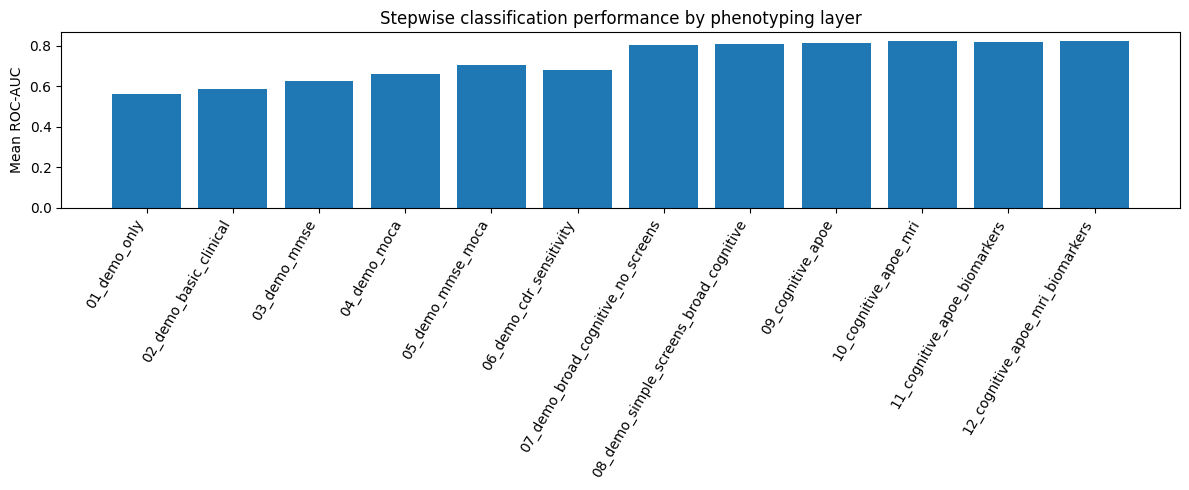

Caption: This shows how prediction improves as more phenotyping layers are added.


,feature_set,model,n_features,roc_auc_mean,roc_auc_sd,pr_auc_mean,balanced_accuracy_mean,sensitivity_mean,specificity_mean,f1_mean,youden_j_mean
1,01_demo_only,logistic_l1,6,0.563044,0.047750,0.300680,0.559497,0.662772,0.456222,0.412550,0.118994
6,02_demo_basic_clinical,logistic_l2,22,0.588285,0.032133,0.316582,0.575062,0.685849,0.464275,0.426428,0.150124
9,03_demo_mmse,logistic_l1,7,0.625621,0.050913,0.350678,0.612310,0.777794,0.446826,0.463768,0.224620
13,04_demo_moca,logistic_l1,49,0.660841,0.024321,0.387609,0.629825,0.601524,0.658126,0.466420,0.259650
17,05_demo_mmse_moca,logistic_l1,50,0.705095,0.033913,0.415437,0.677126,0.743251,0.611001,0.520870,0.354252
21,06_demo_cdr_sensitivity,logistic_l1,8,0.682337,0.060832,0.404260,0.645110,0.831205,0.459015,0.492843,0.290220
27,07_demo_broad_cognitive_no_screens,random_forest,56,0.803525,0.031057,0.585160,0.646075,0.375544,0.916606,0.465524,0.292150
31,08_demo_simple_screens_broad_cognitive,random_forest,100,0.810632,0.035722,0.591524,0.648443,0.387010,0.909877,0.470828,0.296887
35,09_cognitive_apoe,random_forest,101,0.814271,0.025956,0.603380,0.654466,0.386938,0.921993,0.481493,0.308931
39,10_cognitive_apoe_mri,random_forest,749,0.823123,0.038647,0.636929,0.664946,0.398476,0.931417,0.500742,0.329893


In [28]:
if not classification_summary.empty:
    best_by_set = (
        classification_summary
        .sort_values("roc_auc_mean", ascending=False)
        .groupby("feature_set")
        .head(1)
        .sort_values("feature_set")
    )

    plt.figure(figsize=(12, 5))
    plt.bar(best_by_set["feature_set"], best_by_set["roc_auc_mean"])
    plt.xticks(rotation=60, ha="right")
    plt.ylabel("Mean ROC-AUC")
    plt.title("Stepwise classification performance by phenotyping layer")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "stepwise_auc_bar.png", dpi=200)
    plt.show()

    show_caption("This shows how prediction improves as more phenotyping layers are added.")
    display(best_by_set)

# 9. Incremental value and burden analysis

This section shows which added phenotyping layer improves prediction the most and whether the added burden appears justified.

,outcome,base_step,added_step,base_auc,new_auc,delta_auc
0,MCI_to_dementia_2yr,01_demo_only,02_demo_basic_clinical,0.563044,0.588285,0.025241
1,MCI_to_dementia_2yr,02_demo_basic_clinical,03_demo_mmse,0.588285,0.625621,0.037336
2,MCI_to_dementia_2yr,03_demo_mmse,04_demo_moca,0.625621,0.660841,0.035219
3,MCI_to_dementia_2yr,04_demo_moca,05_demo_mmse_moca,0.660841,0.705095,0.044255
4,MCI_to_dementia_2yr,05_demo_mmse_moca,06_demo_cdr_sensitivity,0.705095,0.682337,-0.022758
5,MCI_to_dementia_2yr,06_demo_cdr_sensitivity,07_demo_broad_cognitive_no_screens,0.682337,0.803525,0.121189
6,MCI_to_dementia_2yr,07_demo_broad_cognitive_no_screens,08_demo_simple_screens_broad_cognitive,0.803525,0.810632,0.007106
7,MCI_to_dementia_2yr,08_demo_simple_screens_broad_cognitive,09_cognitive_apoe,0.810632,0.814271,0.003639
8,MCI_to_dementia_2yr,09_cognitive_apoe,10_cognitive_apoe_mri,0.814271,0.823123,0.008853
9,MCI_to_dementia_2yr,10_cognitive_apoe_mri,11_cognitive_apoe_biomarkers,0.823123,0.820718,-0.002406


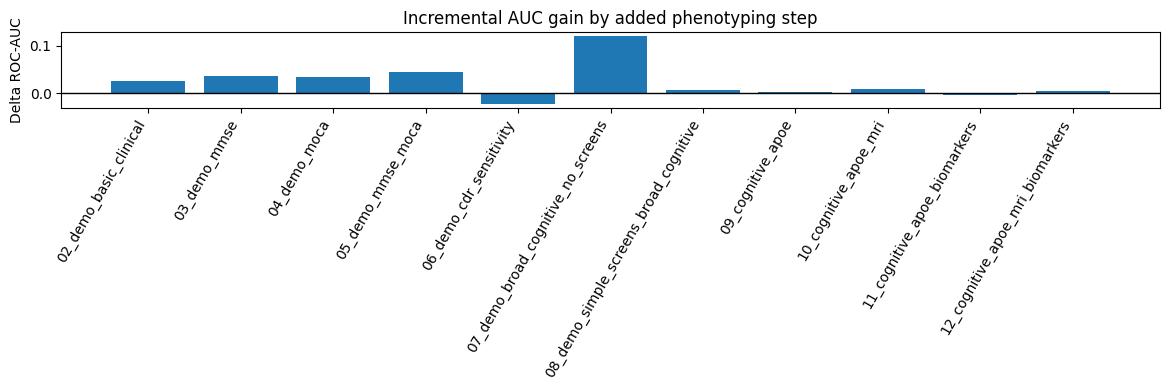

Caption: This shows which additional data layer produces the largest performance gain.


In [29]:
def compute_incremental_classification(summary_df):
    if summary_df.empty:
        return pd.DataFrame()

    best = (
        summary_df.sort_values("roc_auc_mean", ascending=False)
        .groupby("feature_set")
        .head(1)
        .sort_values("feature_set")
        .reset_index(drop=True)
    )

    rows = []
    for i in range(1, len(best)):
        prev = best.iloc[i - 1]
        cur = best.iloc[i]

        rows.append({
            "outcome": "MCI_to_dementia_2yr",
            "base_step": prev["feature_set"],
            "added_step": cur["feature_set"],
            "base_auc": prev["roc_auc_mean"],
            "new_auc": cur["roc_auc_mean"],
            "delta_auc": cur["roc_auc_mean"] - prev["roc_auc_mean"],
        })

    return pd.DataFrame(rows)


incremental_classification = compute_incremental_classification(classification_summary)
display(incremental_classification)
incremental_classification.to_csv(OUTPUT_DIR / "incremental_value_results.csv", index=False)

if not incremental_classification.empty:
    plt.figure(figsize=(12, 4))
    plt.bar(incremental_classification["added_step"], incremental_classification["delta_auc"])
    plt.xticks(rotation=60, ha="right")
    plt.axhline(0, color="black", linewidth=1)
    plt.ylabel("Delta ROC-AUC")
    plt.title("Incremental AUC gain by added phenotyping step")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "incremental_auc_gain.png", dpi=200)
    plt.show()

    show_caption("This shows which additional data layer produces the largest performance gain.")

,feature_set,model,roc_auc_mean,burden_score,auc_per_burden
47,12_cognitive_apoe_mri_biomarkers,random_forest,0.825777,16.75,0.049300
39,10_cognitive_apoe_mri,random_forest,0.823123,12.75,0.064559
43,11_cognitive_apoe_biomarkers,random_forest,0.820718,6.75,0.121588
35,09_cognitive_apoe,random_forest,0.814271,2.75,0.296098
31,08_demo_simple_screens_broad_cognitive,random_forest,0.810632,2.50,0.324253
27,07_demo_broad_cognitive_no_screens,random_forest,0.803525,2.50,0.321410
17,05_demo_mmse_moca,logistic_l1,0.705095,2.50,0.282038
21,06_demo_cdr_sensitivity,logistic_l1,0.682337,1.50,0.454891
13,04_demo_moca,logistic_l1,0.660841,1.50,0.440560
9,03_demo_mmse,logistic_l1,0.625621,1.50,0.417081


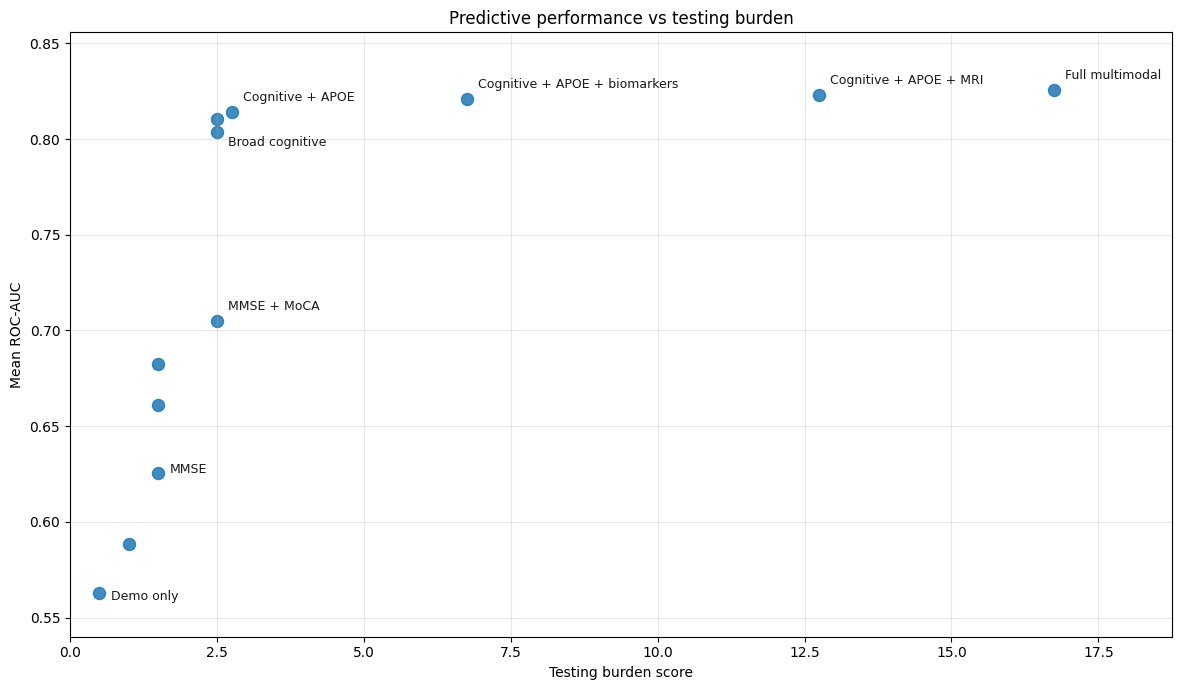

Caption: This visualizes the tradeoff between predictive performance and phenotyping burden. Only key model stages are labeled for readability.


In [32]:
BURDEN = {
    "demographics": 0.5,
    "basic_clinical": 0.5,
    "mmse": 1.0,
    "moca": 1.0,
    "cdr": 1.0,
    "broad_cognitive": 2.0,
    "apoe": 0.75,
    "mri": 10.0,
    "biomarkers": 4.0,
}

def burden_for_feature_set(name):
    score = 0.0
    if "demo" in name:
        score += BURDEN["demographics"]
    if "basic_clinical" in name:
        score += BURDEN["basic_clinical"]
    if "mmse" in name:
        score += BURDEN["mmse"]
    if "moca" in name:
        score += BURDEN["moca"]
    if "cdr" in name:
        score += BURDEN["cdr"]
    if "broad_cognitive" in name or "cognitive" in name:
        score += BURDEN["broad_cognitive"]
    if "apoe" in name:
        score += BURDEN["apoe"]
    if "mri" in name:
        score += BURDEN["mri"]
    if "biomarker" in name:
        score += BURDEN["biomarkers"]
    return score


if not classification_summary.empty:
    burden_df = (
        classification_summary
        .sort_values("roc_auc_mean", ascending=False)
        .groupby("feature_set")
        .head(1)
        .copy()
    )
    burden_df["burden_score"] = burden_df["feature_set"].apply(burden_for_feature_set)
    burden_df["auc_per_burden"] = burden_df["roc_auc_mean"] / burden_df["burden_score"].replace(0, np.nan)
    burden_df = burden_df.sort_values("roc_auc_mean", ascending=False)

    display(burden_df[["feature_set", "model", "roc_auc_mean", "burden_score", "auc_per_burden"]])
    burden_df.to_csv(OUTPUT_DIR / "burden_tradeoff_results.csv", index=False)

plt.figure(figsize=(12, 7))

plt.scatter(
    burden_df["burden_score"],
    burden_df["roc_auc_mean"],
    s=75,
    alpha=0.85
)

# Only label the key points needed for interpretation
key_feature_sets = [
    "01_demo_only",
    "03_demo_mmse",
    "05_demo_mmse_moca",
    "07_demo_broad_cognitive_no_screens",
    "09_cognitive_apoe",
    "10_cognitive_apoe_mri",
    "11_cognitive_apoe_biomarkers",
    "12_cognitive_apoe_mri_biomarkers",
]

label_offsets = {
    "01_demo_only": (8, -5),
    "03_demo_mmse": (8, 0),
    "05_demo_mmse_moca": (8, 8),
    "07_demo_broad_cognitive_no_screens": (8, -10),
    "09_cognitive_apoe": (8, 8),
    "10_cognitive_apoe_mri": (8, 8),
    "11_cognitive_apoe_biomarkers": (8, 8),
    "12_cognitive_apoe_mri_biomarkers": (8, 8),
}

short_labels = {
    "01_demo_only": "Demo only",
    "03_demo_mmse": "MMSE",
    "05_demo_mmse_moca": "MMSE + MoCA",
    "07_demo_broad_cognitive_no_screens": "Broad cognitive",
    "09_cognitive_apoe": "Cognitive + APOE",
    "10_cognitive_apoe_mri": "Cognitive + APOE + MRI",
    "11_cognitive_apoe_biomarkers": "Cognitive + APOE + biomarkers",
    "12_cognitive_apoe_mri_biomarkers": "Full multimodal",
}

for _, row in burden_df.iterrows():
    fs = row["feature_set"]
    if fs not in key_feature_sets:
        continue

    dx_offset, dy_offset = label_offsets.get(fs, (8, 8))

    plt.annotate(
        short_labels[fs],
        (row["burden_score"], row["roc_auc_mean"]),
        xytext=(dx_offset, dy_offset),
        textcoords="offset points",
        fontsize=9,
        alpha=0.9
    )

plt.xlabel("Testing burden score")
plt.ylabel("Mean ROC-AUC")
plt.title("Predictive performance vs testing burden")
plt.grid(True, alpha=0.3)

plt.xlim(0, burden_df["burden_score"].max() + 2)
plt.ylim(0.54, burden_df["roc_auc_mean"].max() + 0.03)

plt.tight_layout()
plt.savefig(FIG_DIR / "performance_vs_burden_clean_labeled.png", dpi=300, bbox_inches="tight")
plt.show()

print("Caption: This visualizes the tradeoff between predictive performance and phenotyping burden. Only key model stages are labeled for readability.")

# 10. Stepwise regression models for MMSE/MoCA/CDR-SB change

This section predicts continuous decline outcomes. For each outcome, baseline score is included in all models after the demographics-only model because baseline cognitive level is clinically meaningful.

In [33]:
def regressor_models():
    return {
        "linear_regression": LinearRegression(),
        "ridge": Ridge(alpha=1.0),
        "random_forest_regressor": RandomForestRegressor(
            n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1
        ),
        "extra_trees_regressor": ExtraTreesRegressor(
            n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1
        ),
    }


def rmse_score(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def evaluate_regression_cv(df, outcome_col, features, label, n_splits=5):
    features = valid_cols(features, df=df)
    if not features:
        print(f"SKIP {label} | {outcome_col}: no valid features")
        return pd.DataFrame()

    work = df.dropna(subset=[outcome_col]).copy()
    if work.shape[0] < 100:
        print(f"SKIP {outcome_col}: only {work.shape[0]} rows")
        return pd.DataFrame()

    X = work[features].copy()
    y = work[outcome_col].astype(float)
    groups = work["RID"]

    cv = GroupKFold(n_splits=min(n_splits, groups.nunique()))
    rows = []

    for model_name, model in regressor_models().items():
        print(f"{outcome_col} | {label} | {model_name} | {len(features)} features | n={len(work)}")

        for fold, (train_idx, test_idx) in enumerate(cv.split(X, y, groups), start=1):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            pipe = Pipeline(steps=[
                ("preprocess", build_preprocessor(X_train)),
                ("model", model),
            ])

            try:
                pipe.fit(X_train, y_train)
                y_pred = pipe.predict(X_test)

                rows.append({
                    "outcome": outcome_col,
                    "feature_set": label,
                    "model": model_name,
                    "fold": fold,
                    "n_features": len(features),
                    "features": " | ".join(features),
                    "r2": r2_score(y_test, y_pred),
                    "rmse": rmse_score(y_test, y_pred),
                    "mae": mean_absolute_error(y_test, y_pred),
                    "median_ae": median_absolute_error(y_test, y_pred),
                })
            except Exception as e:
                print(f"  Fold failed for {outcome_col} | {label} | {model_name} | fold {fold}: {e}")

    return pd.DataFrame(rows)


def summarize_regression_results(fold_df):
    if fold_df.empty:
        return pd.DataFrame()

    return (
        fold_df
        .groupby(["outcome", "feature_set", "model"])
        .agg(
            n_features=("n_features", "first"),
            r2_mean=("r2", "mean"),
            r2_sd=("r2", "std"),
            rmse_mean=("rmse", "mean"),
            mae_mean=("mae", "mean"),
            median_ae_mean=("median_ae", "mean"),
        )
        .reset_index()
        .sort_values(["outcome", "r2_mean"], ascending=[True, False])
    )

In [34]:
regression_model = analysis_model.copy()

for change_df, prefix in [
    (mmse_change, "MMSE"),
    (moca_change, "MOCA"),
    (cdr_change, "CDRSB"),
]:
    if not change_df.empty:
        keep_cols = [c for c in change_df.columns if c == "RID" or c.startswith(prefix)]
        regression_model = regression_model.merge(change_df[keep_cols], on="RID", how="left")

print("regression_model:", regression_model.shape)

regression_feature_sets = {
    "01_demo_only": demo_cols,
    "02_demo_baseline_score": demo_cols,
    "03_demo_score_broad_cognitive": demo_cols + broad_cog_cols,
    "04_score_cognitive_apoe": demo_cols + broad_cog_cols + apoe_cols,
    "05_score_cognitive_apoe_mri": demo_cols + broad_cog_cols + apoe_cols + mri_cols,
}

if biomarker_cols:
    regression_feature_sets["06_score_cognitive_apoe_mri_biomarkers"] = (
        demo_cols + broad_cog_cols + apoe_cols + mri_cols + biomarker_cols
    )

outcome_baseline_cols = {
    "MMSE_change_2yr": [c for c in regression_model.columns if c == "MMSE_baseline"],
    "MOCA_change_2yr": [c for c in regression_model.columns if c == "MOCA_baseline"],
    "CDRSB_change_2yr": [c for c in regression_model.columns if c == "CDRSB_baseline"],
}

regression_results = []

for outcome_col, baseline_cols in outcome_baseline_cols.items():
    if outcome_col not in regression_model.columns:
        print("Skipping missing outcome:", outcome_col)
        continue

    n = regression_model[outcome_col].notna().sum()
    print("\nOutcome:", outcome_col, "| n:", n)

    for label, feats in regression_feature_sets.items():
        feats_use = feats.copy()
        if label != "01_demo_only":
            feats_use = baseline_cols + feats_use

        res = evaluate_regression_cv(regression_model, outcome_col, feats_use, label, n_splits=5)
        if not res.empty:
            regression_results.append(res)

regression_fold_results = pd.concat(regression_results, ignore_index=True) if regression_results else pd.DataFrame()
regression_summary = summarize_regression_results(regression_fold_results)

display(regression_summary)

regression_fold_results.to_csv(OUTPUT_DIR / "stepwise_regression_fold_results.csv", index=False)
regression_summary.to_csv(OUTPUT_DIR / "stepwise_regression_summary.csv", index=False)

regression_model: (1004, 1242)

Outcome: MMSE_change_2yr | n: 892
MMSE_change_2yr | 01_demo_only | linear_regression | 6 features | n=892
MMSE_change_2yr | 01_demo_only | ridge | 6 features | n=892
MMSE_change_2yr | 01_demo_only | random_forest_regressor | 6 features | n=892
MMSE_change_2yr | 01_demo_only | extra_trees_regressor | 6 features | n=892
MMSE_change_2yr | 02_demo_baseline_score | linear_regression | 7 features | n=892
MMSE_change_2yr | 02_demo_baseline_score | ridge | 7 features | n=892
MMSE_change_2yr | 02_demo_baseline_score | random_forest_regressor | 7 features | n=892
MMSE_change_2yr | 02_demo_baseline_score | extra_trees_regressor | 7 features | n=892
MMSE_change_2yr | 03_demo_score_broad_cognitive | linear_regression | 57 features | n=892
MMSE_change_2yr | 03_demo_score_broad_cognitive | ridge | 57 features | n=892
MMSE_change_2yr | 03_demo_score_broad_cognitive | random_forest_regressor | 57 features | n=892
MMSE_change_2yr | 03_demo_score_broad_cognitive | extra_tr

,outcome,feature_set,model,n_features,r2_mean,r2_sd,rmse_mean,mae_mean,median_ae_mean
18,CDRSB_change_2yr,05_score_cognitive_apoe_mri,random_forest_regressor,706,0.165294,0.026470,1.664823,1.196776,0.897833
22,CDRSB_change_2yr,06_score_cognitive_apoe_mri_biomarkers,random_forest_regressor,719,0.152744,0.039763,1.676262,1.201420,0.890333
16,CDRSB_change_2yr,05_score_cognitive_apoe_mri,extra_trees_regressor,706,0.147301,0.052895,1.680356,1.205546,0.908500
14,CDRSB_change_2yr,04_score_cognitive_apoe,random_forest_regressor,58,0.145513,0.053132,1.685034,1.200844,0.902167
20,CDRSB_change_2yr,06_score_cognitive_apoe_mri_biomarkers,extra_trees_regressor,719,0.141946,0.054339,1.685715,1.205764,0.903500
8,CDRSB_change_2yr,03_demo_score_broad_cognitive,extra_trees_regressor,57,0.137053,0.031070,1.692242,1.202638,0.892833
10,CDRSB_change_2yr,03_demo_score_broad_cognitive,random_forest_regressor,57,0.135809,0.054120,1.694340,1.207874,0.899500
12,CDRSB_change_2yr,04_score_cognitive_apoe,extra_trees_regressor,58,0.130366,0.034590,1.698205,1.211090,0.891500
15,CDRSB_change_2yr,04_score_cognitive_apoe,ridge,58,0.097848,0.029895,1.731503,1.242745,0.936253
13,CDRSB_change_2yr,04_score_cognitive_apoe,linear_regression,58,0.086101,0.028353,1.743055,1.250130,0.939355


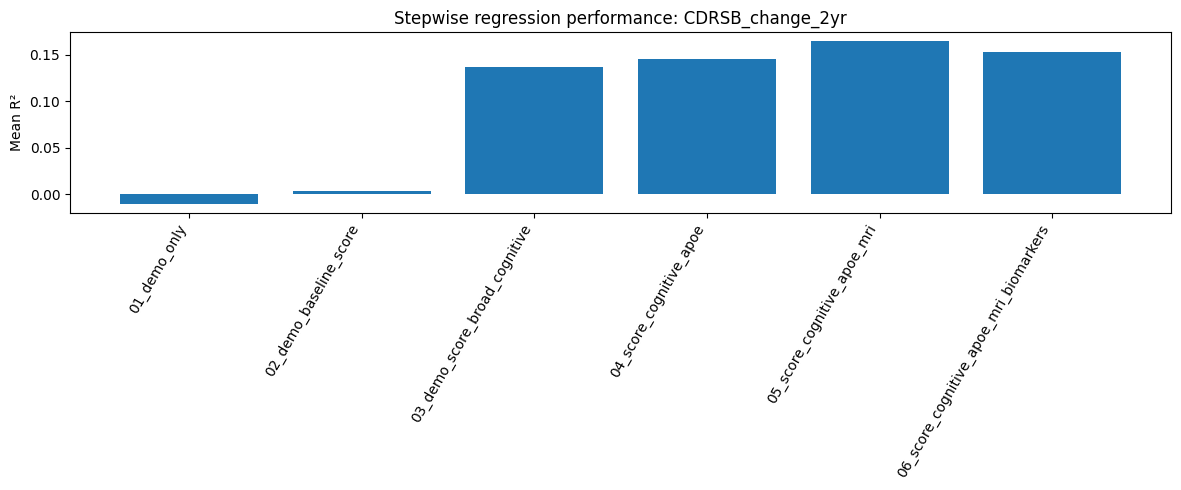

Caption: This shows how much variance in CDRSB_change_2yr is explained by each phenotyping level.


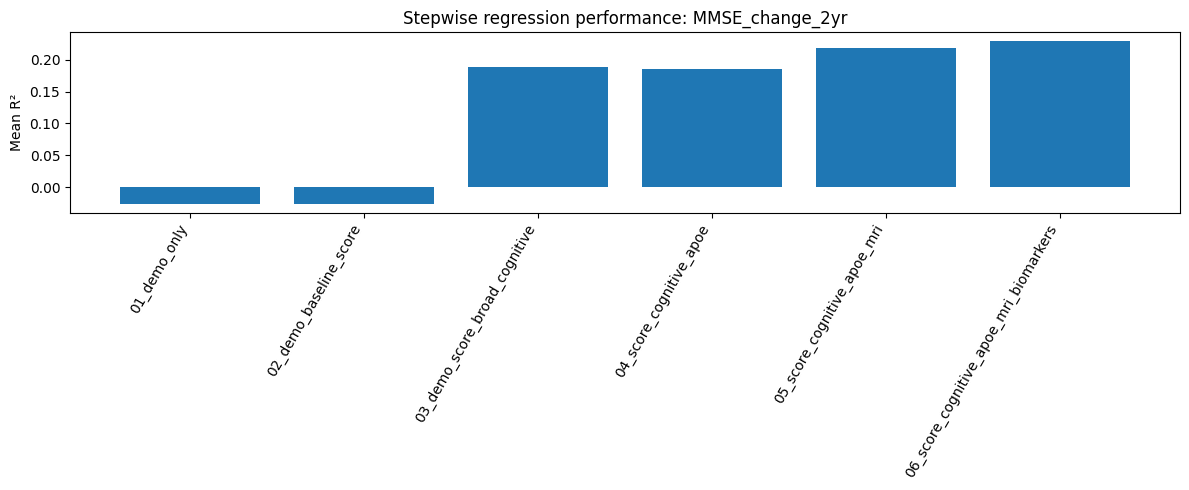

Caption: This shows how much variance in MMSE_change_2yr is explained by each phenotyping level.


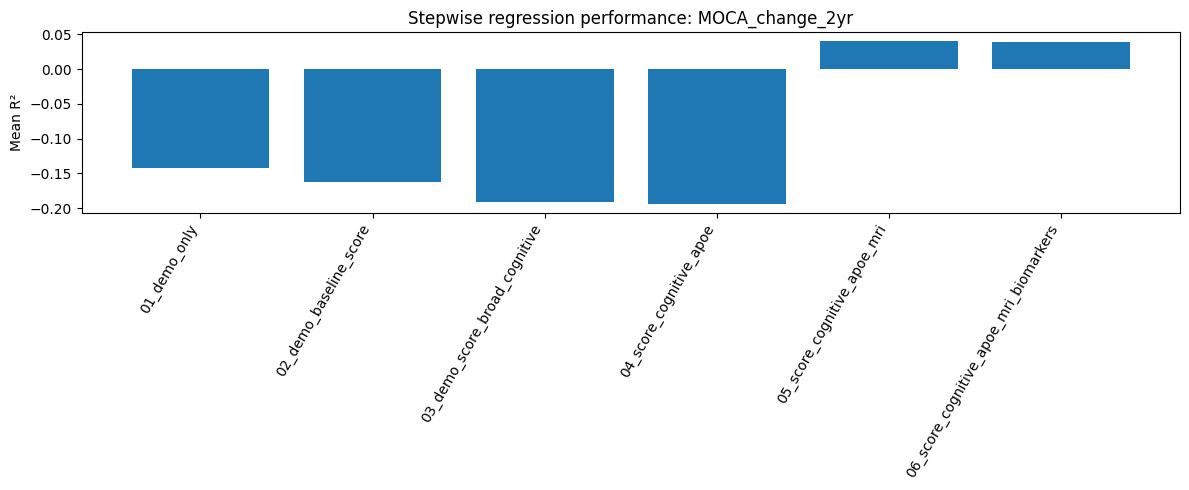

Caption: This shows how much variance in MOCA_change_2yr is explained by each phenotyping level.


In [35]:
if not regression_summary.empty:
    for outcome in regression_summary["outcome"].unique():
        best_by_set = (
            regression_summary[regression_summary["outcome"] == outcome]
            .sort_values("r2_mean", ascending=False)
            .groupby("feature_set")
            .head(1)
            .sort_values("feature_set")
        )

        plt.figure(figsize=(12, 5))
        plt.bar(best_by_set["feature_set"], best_by_set["r2_mean"])
        plt.xticks(rotation=60, ha="right")
        plt.ylabel("Mean R²")
        plt.title(f"Stepwise regression performance: {outcome}")
        plt.tight_layout()
        plt.savefig(FIG_DIR / f"{outcome.lower()}_stepwise_r2.png", dpi=200)
        plt.show()

        show_caption(f"This shows how much variance in {outcome} is explained by each phenotyping level.")

# 11. Feature stability

This section counts which features have non-zero LASSO coefficients across grouped CV folds for the best LASSO feature set.

Best LASSO feature set: 11_cognitive_apoe_biomarkers


,feature,selection_count,feature_set
0,PTDEMOG__PTEDUCAT,5,11_cognitive_apoe_biomarkers
25,NEUROBAT__TRABERROM,5,11_cognitive_apoe_biomarkers
27,NEUROBAT__LDELTOTAL,5,11_cognitive_apoe_biomarkers
28,NEUROBAT__AVDELBEGAN,5,11_cognitive_apoe_biomarkers
31,NEUROBAT__AVDELTOT,5,11_cognitive_apoe_biomarkers
32,NEUROBAT__AVDELERR2,5,11_cognitive_apoe_biomarkers
33,NEUROBAT__ANARTERR,5,11_cognitive_apoe_biomarkers
35,UWNPSYCHSUM__ADNI_LAN,5,11_cognitive_apoe_biomarkers
36,APOE4_count,5,11_cognitive_apoe_biomarkers
42,UPENNBIOMK_ROCHE_ELECSYS__ABETA42,5,11_cognitive_apoe_biomarkers


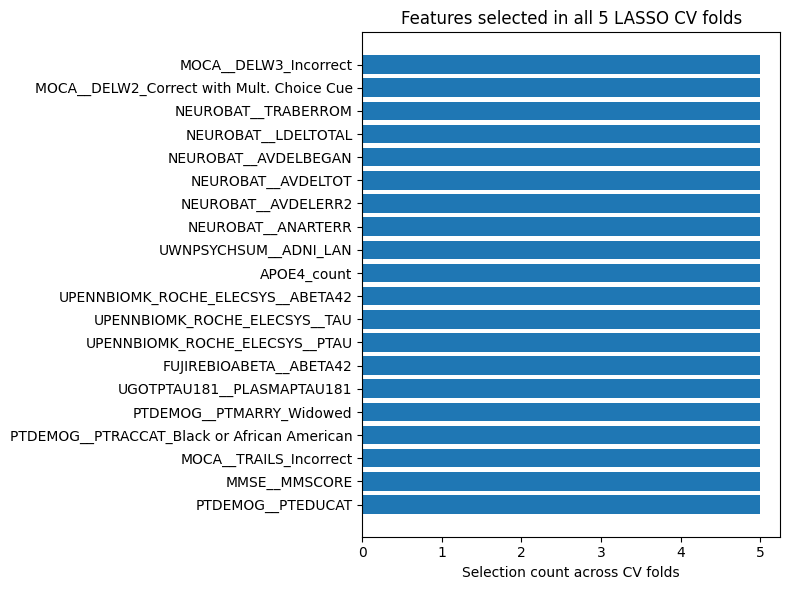

Caption: This shows which markers repeatedly contribute to prediction across resampling folds.


In [37]:
def get_feature_names_from_preprocessor(preprocessor):
    names = []
    for name, transformer, cols in preprocessor.transformers_:
        if name == "remainder":
            continue

        if hasattr(transformer, "named_steps"):
            last_step = list(transformer.named_steps.values())[-1]
            if hasattr(last_step, "get_feature_names_out"):
                try:
                    names.extend(last_step.get_feature_names_out(cols))
                except Exception:
                    names.extend(cols)
            else:
                names.extend(cols)
        else:
            names.extend(cols)

    return list(names)


def lasso_stability(df, features, label, n_splits=5):
    features = valid_cols(features, df=df)
    if not features:
        return pd.DataFrame()

    X = df[features].copy()
    y = df[TARGET_COL].astype(int)
    groups = df["RID"]

    cv = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    counts = {}

    for fold, (train_idx, test_idx) in enumerate(cv.split(X, y, groups), start=1):
        X_train = X.iloc[train_idx]
        y_train = y.iloc[train_idx]

        pipe = Pipeline(steps=[
            ("preprocess", build_preprocessor(X_train)),
            ("model", LogisticRegression(
                penalty="l1",
                solver="liblinear",
                class_weight="balanced",
                max_iter=5000,
                random_state=RANDOM_STATE,
            )),
        ])

        try:
            pipe.fit(X_train, y_train)
            feature_names = get_feature_names_from_preprocessor(pipe.named_steps["preprocess"])
            coefs = pipe.named_steps["model"].coef_.ravel()

            for fname, coef in zip(feature_names, coefs):
                if abs(coef) > 1e-8:
                    counts[fname] = counts.get(fname, 0) + 1
        except Exception as e:
            print("Stability fold failed:", e)

    out = pd.DataFrame({
        "feature": list(counts.keys()),
        "selection_count": list(counts.values()),
    }).sort_values("selection_count", ascending=False)

    out["feature_set"] = label
    return out


if not classification_summary.empty:
    lasso_summary = classification_summary[classification_summary["model"] == "logistic_l1"].copy()

    if not lasso_summary.empty:
        best_lasso_row = lasso_summary.sort_values("roc_auc_mean", ascending=False).iloc[0]
        best_lasso_set = best_lasso_row["feature_set"]
        print("Best LASSO feature set:", best_lasso_set)

        stability_df = lasso_stability(analysis_model, stepwise_feature_sets[best_lasso_set], best_lasso_set)
        display(stability_df.head(25))
        stability_df.to_csv(OUTPUT_DIR / "feature_stability_results.csv", index=False)

        if not stability_df.empty:
            top = stability_df.head(20).sort_values("selection_count")

            plt.figure(figsize=(8, 6))
            plt.barh(top["feature"], top["selection_count"])
            plt.xlabel("Selection count across CV folds")
            plt.title("Features selected in all 5 LASSO CV folds")
            plt.tight_layout()
            plt.savefig(FIG_DIR / "feature_stability.png", dpi=200)
            plt.show()

            show_caption("This shows which markers repeatedly contribute to prediction across resampling folds.")

# 12. Relationship to Notebook 1

Notebook 1 found that small clinical/APOE panels nearly matched MRI-containing panels for **2-year MCI-to-dementia conversion**.

This notebook extends that analysis by testing a Galasko-style stepwise phenotyping ladder:

- demographics
- basic clinical variables
- MMSE/MoCA simple screens
- broader cognitive battery
- APOE genotype
- MRI
- biomarkers, if available

Together, the two notebooks answer:

1. **What minimal marker panel works best?**
2. **How much phenotyping is necessary before prediction performance plateaus?**

# 13. Final interpretation

Run the cell below after all models finish. It prints a compact summary of the best classification and regression results.

In [38]:
def final_interpretation():
    print("FINAL STEPWISE PHENOTYPING SUMMARY")
    print("=" * 70)

    if not classification_summary.empty:
        best_cls = classification_summary.sort_values("roc_auc_mean", ascending=False).iloc[0]
        print("\nBest classification model for 2-year MCI-to-dementia conversion:")
        print(f"Feature set: {best_cls['feature_set']}")
        print(f"Model: {best_cls['model']}")
        print(f"ROC-AUC: {best_cls['roc_auc_mean']:.3f}")
        print(f"PR-AUC: {best_cls['pr_auc_mean']:.3f}")
        print(f"Sensitivity: {best_cls['sensitivity_mean']:.3f}")
        print(f"Specificity: {best_cls['specificity_mean']:.3f}")

        best_by_set = (
            classification_summary.sort_values("roc_auc_mean", ascending=False)
            .groupby("feature_set")
            .head(1)
            .sort_values("feature_set")
        )

        print("\nBest ROC-AUC by phenotyping step:")
        display(best_by_set[[
            "feature_set", "model", "n_features", "roc_auc_mean",
            "pr_auc_mean", "sensitivity_mean", "specificity_mean"
        ]])

    if not regression_summary.empty:
        print("\nBest regression models for cognitive decline outcomes:")
        best_reg = (
            regression_summary.sort_values("r2_mean", ascending=False)
            .groupby("outcome")
            .head(1)
        )
        display(best_reg[["outcome", "feature_set", "model", "r2_mean", "rmse_mean", "mae_mean"]])

    print("\nInterpretation guide:")
    print("- If performance jumps after MMSE/MoCA, simple cognitive screening carries major signal.")
    print("- If broad cognitive features improve beyond MMSE/MoCA, deeper cognitive phenotyping adds value.")
    print("- If APOE improves performance, genetic risk adds incremental prognostic value.")
    print("- If MRI or biomarkers add only small gains, lower-burden clinical/cognitive information may capture much of the 2-year progression signal.")
    print("- Avoid MRI region-level biological claims until FreeSurfer ST codes are mapped to anatomical labels.")


final_interpretation()

FINAL STEPWISE PHENOTYPING SUMMARY

Best classification model for 2-year MCI-to-dementia conversion:
Feature set: 12_cognitive_apoe_mri_biomarkers
Model: random_forest
ROC-AUC: 0.826
PR-AUC: 0.638
Sensitivity: 0.395
Specificity: 0.926

Best ROC-AUC by phenotyping step:


,feature_set,model,n_features,roc_auc_mean,pr_auc_mean,sensitivity_mean,specificity_mean
1,01_demo_only,logistic_l1,6,0.563044,0.300680,0.662772,0.456222
6,02_demo_basic_clinical,logistic_l2,22,0.588285,0.316582,0.685849,0.464275
9,03_demo_mmse,logistic_l1,7,0.625621,0.350678,0.777794,0.446826
13,04_demo_moca,logistic_l1,49,0.660841,0.387609,0.601524,0.658126
17,05_demo_mmse_moca,logistic_l1,50,0.705095,0.415437,0.743251,0.611001
21,06_demo_cdr_sensitivity,logistic_l1,8,0.682337,0.404260,0.831205,0.459015
27,07_demo_broad_cognitive_no_screens,random_forest,56,0.803525,0.585160,0.375544,0.916606
31,08_demo_simple_screens_broad_cognitive,random_forest,100,0.810632,0.591524,0.387010,0.909877
35,09_cognitive_apoe,random_forest,101,0.814271,0.603380,0.386938,0.921993
39,10_cognitive_apoe_mri,random_forest,749,0.823123,0.636929,0.398476,0.931417



Best regression models for cognitive decline outcomes:


,outcome,feature_set,model,r2_mean,rmse_mean,mae_mean
44,MMSE_change_2yr,06_score_cognitive_apoe_mri_biomarkers,extra_trees_regressor,0.229893,2.643497,1.976657
18,CDRSB_change_2yr,05_score_cognitive_apoe_mri,random_forest_regressor,0.165294,1.664823,1.196776
66,MOCA_change_2yr,05_score_cognitive_apoe_mri,random_forest_regressor,0.041260,2.906568,2.250701



Interpretation guide:
- If performance jumps after MMSE/MoCA, simple cognitive screening carries major signal.
- If broad cognitive features improve beyond MMSE/MoCA, deeper cognitive phenotyping adds value.
- If APOE improves performance, genetic risk adds incremental prognostic value.
- If MRI or biomarkers add only small gains, lower-burden clinical/cognitive information may capture much of the 2-year progression signal.
- Avoid MRI region-level biological claims until FreeSurfer ST codes are mapped to anatomical labels.


# 14. Notes and cautions

- This notebook intentionally includes MMSE/MoCA/CDR in specific stepwise models because the scientific question is about how much phenotyping is necessary.
- For a less diagnosis-adjacent comparison, focus on the broad cognitive model that excludes MMSE/MoCA/CDR.
- Biomarker columns vary across ADNI exports. The notebook uses conservative candidate matching and skips missing optional files.
- MRI variables such as `UCSFFSX7__ST99TA` should be described as FreeSurfer structural MRI markers until mapped to anatomical regions.
- This notebook does not prove clinical deployment. It tests whether lower-burden phenotyping may preserve much of the predictive signal.